In [1]:
pwd

'/global/u2/b/bharat/repos/hwconus'

In [2]:
# Calculating heatwaves 
import matplotlib.pyplot as plt
#import intake_esgf
import matplotlib as mpl
import pandas as pd
import xarray as xr
import numpy as np
import os
import statsmodels.formula.api as smf

import datetime as dt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import statsmodels.formula.api as smf
from scipy import ndimage, stats

import pickle
import cftime

from functions import geo_idx  # user-provided helper module (unchanged)
# Set the matplotlib default font size
mpl.rcParams['font.size'] = 16

/global/homes/b/bharat/anaconda3/envs/pyces/lib/python3.9/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


## Notes: CESM2 all hist not available at daily resolution

using this instead: CanESM5

In [3]:
scenarios = ["all", "nat", "ghg"]
files_tmax = {}
files_tmin = {}
files_tmax ["ghg"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-GHG/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin ["ghg"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-GHG/r1i1p1f1/day/tasmin/*/*/*tasmin*"
files_tmax ["nat"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-nat/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin ["nat"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-nat/r1i1p1f1/day/tasmin/*/*/*tasmin*"
files_tmax ["all"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin ["all"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r1i1p1f1/day/tasmin/*/*/*tasmin*"

In [4]:
out_path = "./plots/"

# CanESM5 Files

In [5]:
temp_ext = np.array(["heat", "cold"])
temp_ext_name = ["heat waves", "cold snaps"]

In [6]:
nc_tmax = {}
nc_tmin = {}
for k in scenarios:
    nc_tmax [k] = xr.open_mfdataset(files_tmax[k], 
                            combine='by_coords', 
                            decode_times=True,
                            use_cftime=True)
    nc_tmin [k] = xr.open_mfdataset(files_tmin[k], 
                            combine='by_coords', 
                            decode_times=True,
                            use_cftime=True)

In [7]:
files_tmax_ssp = "/global/cfs/cdirs/m3522/cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp370/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin_ssp = "/global/cfs/cdirs/m3522/cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp370/r1i1p1f1/day/tasmin/*/*/*tasmin*"

# Read datasets using xarray's open_mfdataset
nc_tmax_ssp = xr.open_mfdataset(files_tmax_ssp, 
                            combine='by_coords', 
                            decode_times=True,
                            use_cftime=True)
nc_tmin_ssp = xr.open_mfdataset(files_tmin_ssp, 
                              combine='by_coords',
                              decode_times=True,
                              use_cftime=True)

# Optional: concatenate historical and future datasets
nc_tmax_full = xr.concat([nc_tmax ["all"], nc_tmax_ssp], dim='time')
nc_tmin_full = xr.concat([nc_tmin ["all"], nc_tmin_ssp], dim='time')

In [8]:
# Example bounds
start_date = "1950-01-01"
end_date   = "2014-12-31"

top = 49.345 + 0.5   # north
bottom = 24.743 - 0.5  # south
left = 360 - 124.78 - 0.5   # west, in 0–360 convention
right = 360 - 66.95 + 0.5   # east

conus_t = {"heat": {}, "cold": {}}

for sce in scenarios:
    tmax = nc_tmax[sce].tasmax 
    tmin = nc_tmin[sce].tasmin
    tmax_conus = nc_tmax [sce].sel(
                    time=slice(start_date, end_date),
                    lat=slice(bottom, top),              # note: depends on lat ordering
                    lon=slice(left, right),
                    )
    tmin_conus = nc_tmin [sce].sel(
                    time=slice(start_date, end_date),
                    lat=slice(bottom, top),              # note: depends on lat ordering
                    lon=slice(left, right),
                    )

    conus_t["heat"][sce] = tmax_conus- 273.15
    conus_t["cold"][sce] = tmin_conus- 273.15
    

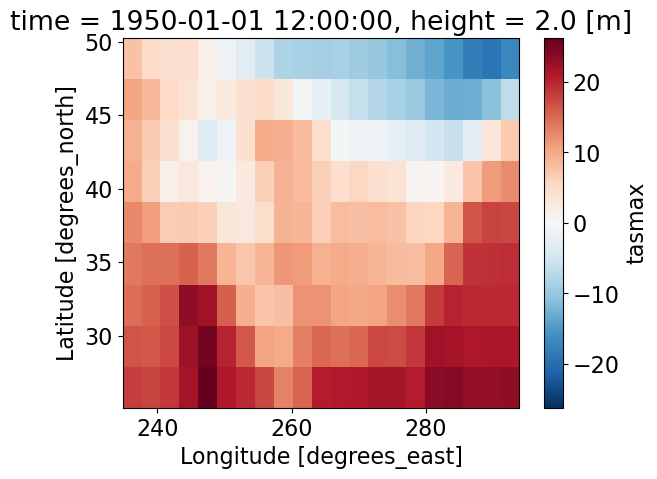

In [92]:
conus_t['heat']['ghg'].tasmax[0].plot()

In [9]:
nc_mask = xr.open_dataset("/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-nat/r1i1p1f1/fx/sftlf/gn/v20190429/sftlf_fx_CanESM5_hist-nat_r1i1p1f1_gn.nc")
ocean_mask = nc_mask.sel(
                    lat=slice(bottom, top),              # note: depends on lat ordering
                    lon=slice(left, right),
                    )
ocean_mask_conus = np.ma.masked_equal(ocean_mask.variables["sftlf"], 0)
ocean_mask_conus_tmax = np.broadcast_to(ocean_mask_conus.mask, conus_t["heat"]["all"].tasmax.shape)

In [10]:
# Bring this to full (time, lat, lon) for tasmax in the "all" scenario:
heat_all_da = conus_t["heat"]["all"].tasmax  # DataArray, shape (time, lat, lon)
ocean_mask_conus_tmax = np.broadcast_to(
    ocean_mask_conus.mask, heat_all_da.shape
)  # bool mask, same shape as tasmax

In [11]:
ocean_mask = nc_mask.sel(
    lat=slice(bottom, top),
    lon=slice(left, right),
)

# 2-D land mask: True on land, False on ocean
land_mask_2d = ocean_mask["sftlf"].values > 0

# Example shape reference
heat_ref = conus_t["heat"]["all"].tasmax.values  # (time, lat, lon)

# 3-D ocean mask: True on ocean, False on land
ocean_mask_3d = np.broadcast_to(~land_mask_2d, heat_ref.shape)

In [95]:
# -----------------------------
# 2. Thresholds
# -----------------------------
th = {
    "heat": {"us": {}, "grid": {}, "sep": {}, "comp": {}, "day_sep": {}, "day_comp": {}, "hdays_py": {}},
    "cold": {"us": {}, "grid": {}, "sep": {}, "comp": {}, "day_sep": {}, "day_comp": {}, "hdays_py": {}},
}

for sce in scenarios:
    heat_arr = conus_t["heat"][sce].tasmax.values   # (time, lat, lon)
    cold_arr = conus_t["cold"][sce].tasmin.values   # (time, lat, lon)

    # Convert ocean to NaN for percentile calculations
    heat_land = np.where(ocean_mask_3d, np.nan, heat_arr)
    cold_land = np.where(ocean_mask_3d, np.nan, cold_arr)

    # US-wide thresholds over all CONUS land points
    th["heat"]["us"][sce] = np.nanpercentile(heat_land, 99)
    th["cold"]["us"][sce] = np.nanpercentile(cold_land, 1)

    # Gridpoint thresholds over time
    th_grid_heat = np.nanpercentile(heat_land, 99, axis=0)   # (lat, lon)
    th_grid_cold = np.nanpercentile(cold_land, 1, axis=0)    # (lat, lon)

    # Mask ocean grid points
    th["heat"]["grid"][sce] = np.ma.array(th_grid_heat, mask=~land_mask_2d)
    th["cold"]["grid"][sce] = np.ma.array(th_grid_cold, mask=~land_mask_2d)


# -----------------------------
# 3. Extreme-day boolean arrays
# -----------------------------
for sce in scenarios:
    for ext in temp_ext:
        if ext == "heat":
            arr = conus_t[ext][sce].tasmax.values
            arr_masked = np.ma.array(arr, mask=ocean_mask_3d)

            th[ext]["sep"][sce] = arr_masked >= th[ext]["grid"][sce]
            th[ext]["comp"][sce] = arr_masked >= th[ext]["grid"]["nat"]

        elif ext == "cold":
            arr = conus_t[ext][sce].tasmin.values
            arr_masked = np.ma.array(arr, mask=ocean_mask_3d)

            th[ext]["sep"][sce] = arr_masked <= th[ext]["grid"][sce]
            th[ext]["comp"][sce] = arr_masked <= th[ext]["grid"]["nat"]




/global/homes/b/bharat/anaconda3/envs/pyces/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [96]:
th["heat"]["us"]

{'all': 42.118438720703125, 'nat': 41.4475714111328, 'ghg': 43.13305725097655}

In [97]:
th["cold"]["us"]

{'all': -29.090828704833985,
 'nat': -29.554085235595704,
 'ghg': -25.99846130371094}

## Read th directly save time to compute every time

In [100]:
if False:
    # Save
    with open("th.pkl", "wb") as f:
        pickle.dump(th, f)

In [12]:
if True:
    # Load
    with open("th.pkl", "rb") as f:
        th = pickle.load(f)

In [13]:
# -----------------------------
# 4. Yearly counts
# -----------------------------
days_per_year = 365
start_year = 1950
yrs = np.array(range(start_year, 2015))
for sce in scenarios:
    for ext in temp_ext:
        count_days_sep = np.zeros((len(yrs), 2))
        count_days_comp = np.zeros((len(yrs), 2))

        # masked array: (year, lat, lon)
        yearly_grid_counts = np.ma.masked_all((len(yrs), land_mask_2d.shape[0], land_mask_2d.shape[1]))

        for idx, yr in enumerate(yrs):
            i0 = idx * days_per_year
            i1 = (idx + 1) * days_per_year

            sep_slice = th[ext]["sep"][sce][i0:i1, :, :]
            comp_slice = th[ext]["comp"][sce][i0:i1, :, :]

            count_days_sep[idx, 0] = yr
            count_days_sep[idx, 1] = np.ma.sum(sep_slice)

            count_days_comp[idx, 0] = yr
            count_days_comp[idx, 1] = np.ma.sum(comp_slice)

            yearly_grid_counts[idx, :, :] = np.ma.sum(comp_slice, axis=0)

        th[ext]["day_sep"][sce] = count_days_sep
        th[ext]["day_comp"][sce] = count_days_comp
        th[ext]["hdays_py"][sce] = yearly_grid_counts

In [14]:
th["heat"]["grid"][sce]

masked_array(
  data=[[--, --, --, 31.569917678833008, 41.48256301879883,
         40.58950424194336, 37.25519561767578, 39.54405212402344,
         41.974693298339844, 42.31731033325195, 31.474058151245117, --,
         --, --, 30.807043075561523, 32.19242858886719,
         30.429773330688477, --, --, --, --],
        [--, --, --, 37.15922546386719, 51.28081130981445,
         44.17496871948242, 40.819095611572266, 42.803611755371094,
         45.18510437011719, 43.20515441894531, 37.638702392578125,
         34.13807678222656, 32.91876220703125, 31.734554290771484,
         33.021812438964844, 34.67718505859375, 30.50758934020996, --,
         --, --, --],
        [--, --, 32.81736373901367, 49.670982360839844, 51.4007453918457,
         44.85435104370117, 43.41810607910156, 44.72804260253906,
         44.48563003540039, 43.54804229736328, 42.977256774902344,
         41.942256927490234, 40.52975845336914, 38.62260055541992,
         38.20075988769531, 36.10805130004883, 31.89914131

# plot

In [16]:
fig_size = (6,4.5)

In [17]:
lats_conus = ocean_mask.lat
lons_conus = ocean_mask.lon
#lats_conus = lats[geo_idx(bottom, lats):geo_idx(top, lats) + 1]
#lons_conus = lons[geo_idx(left, lons):geo_idx(right, lons) + 1]

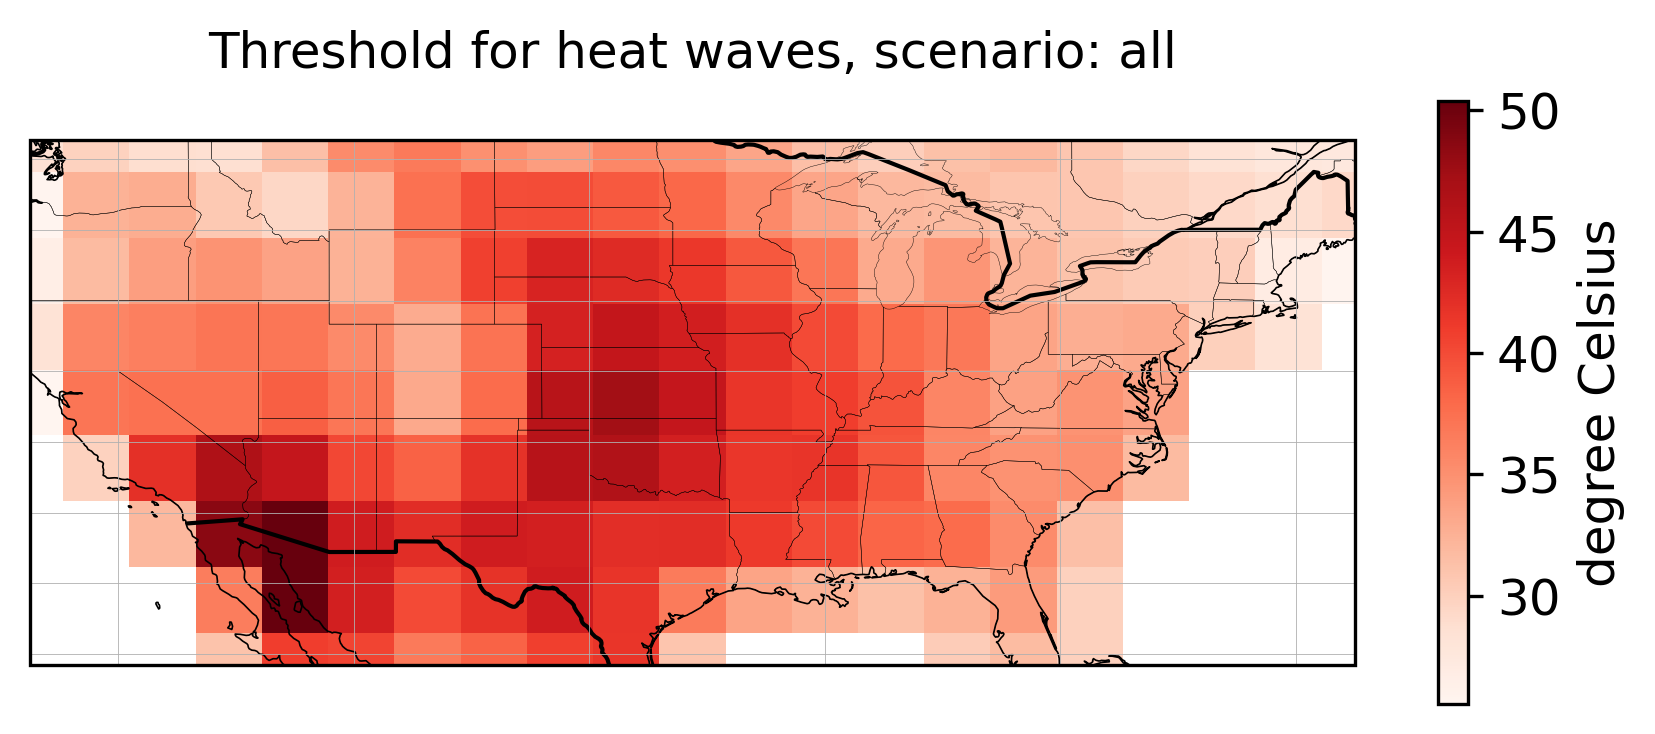

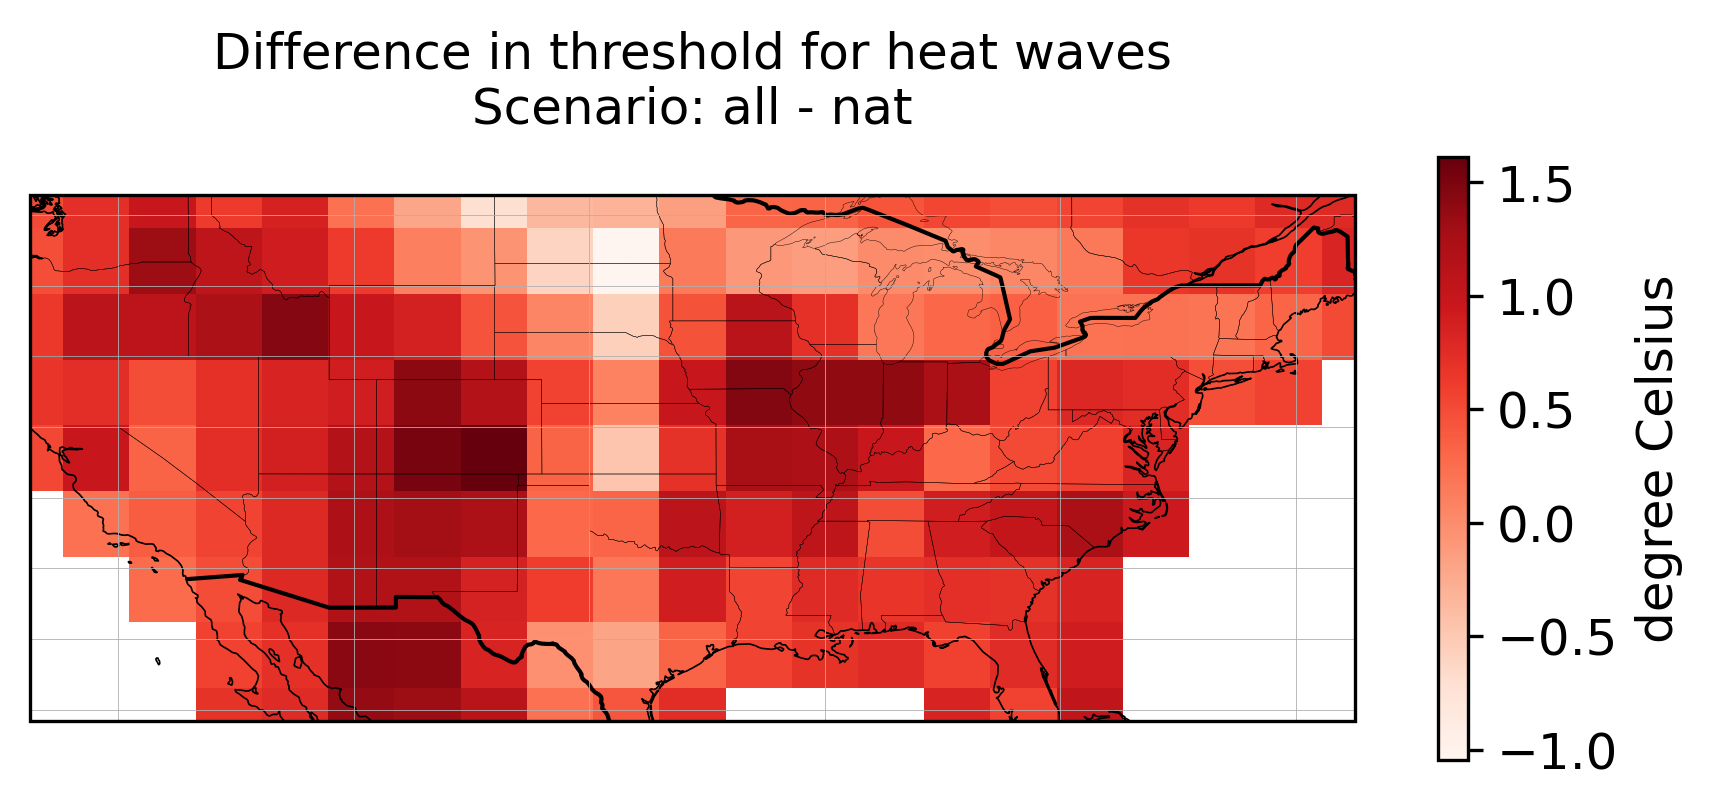

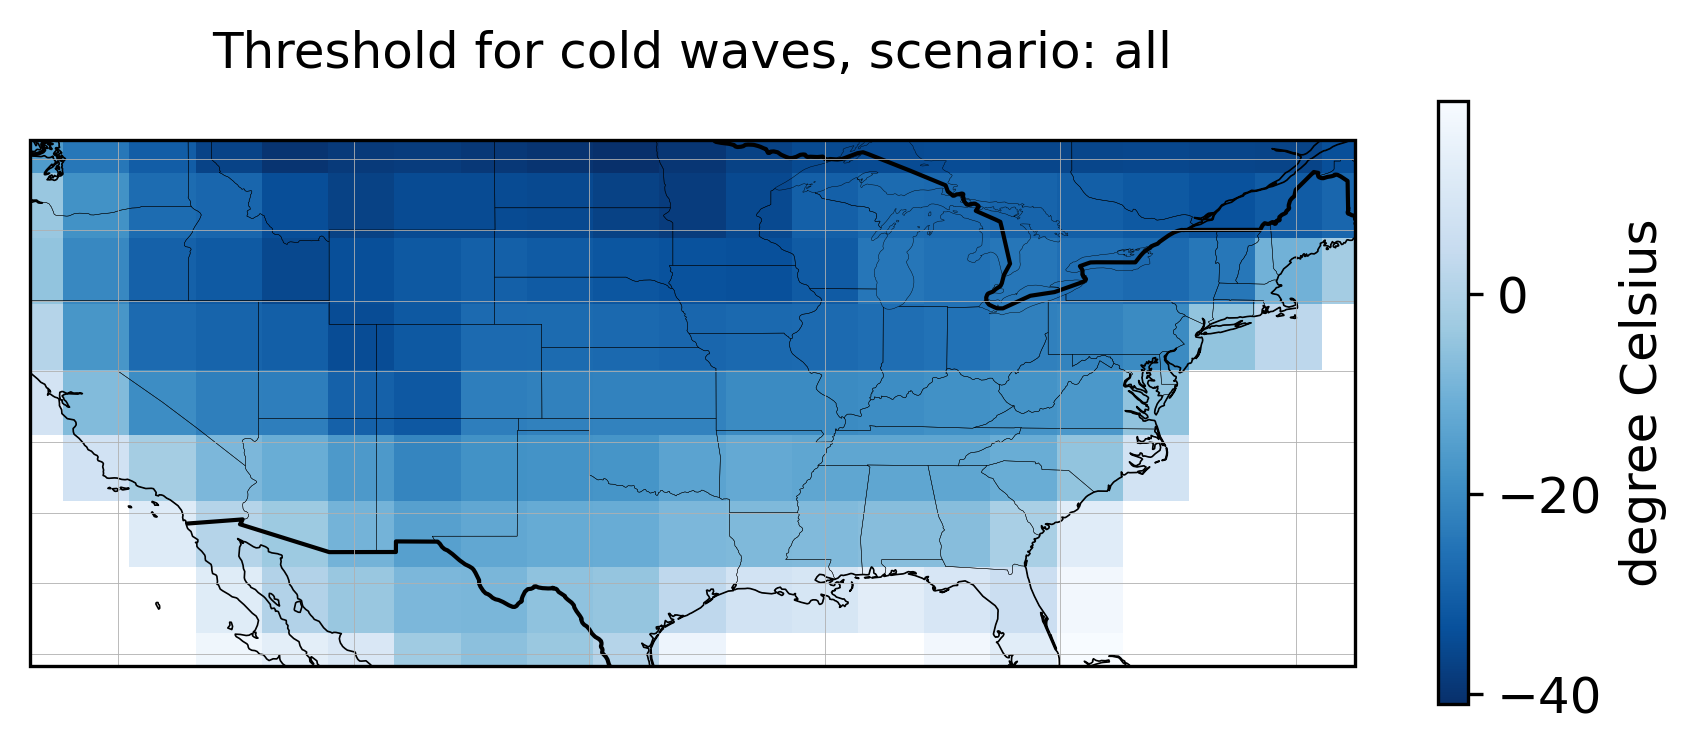

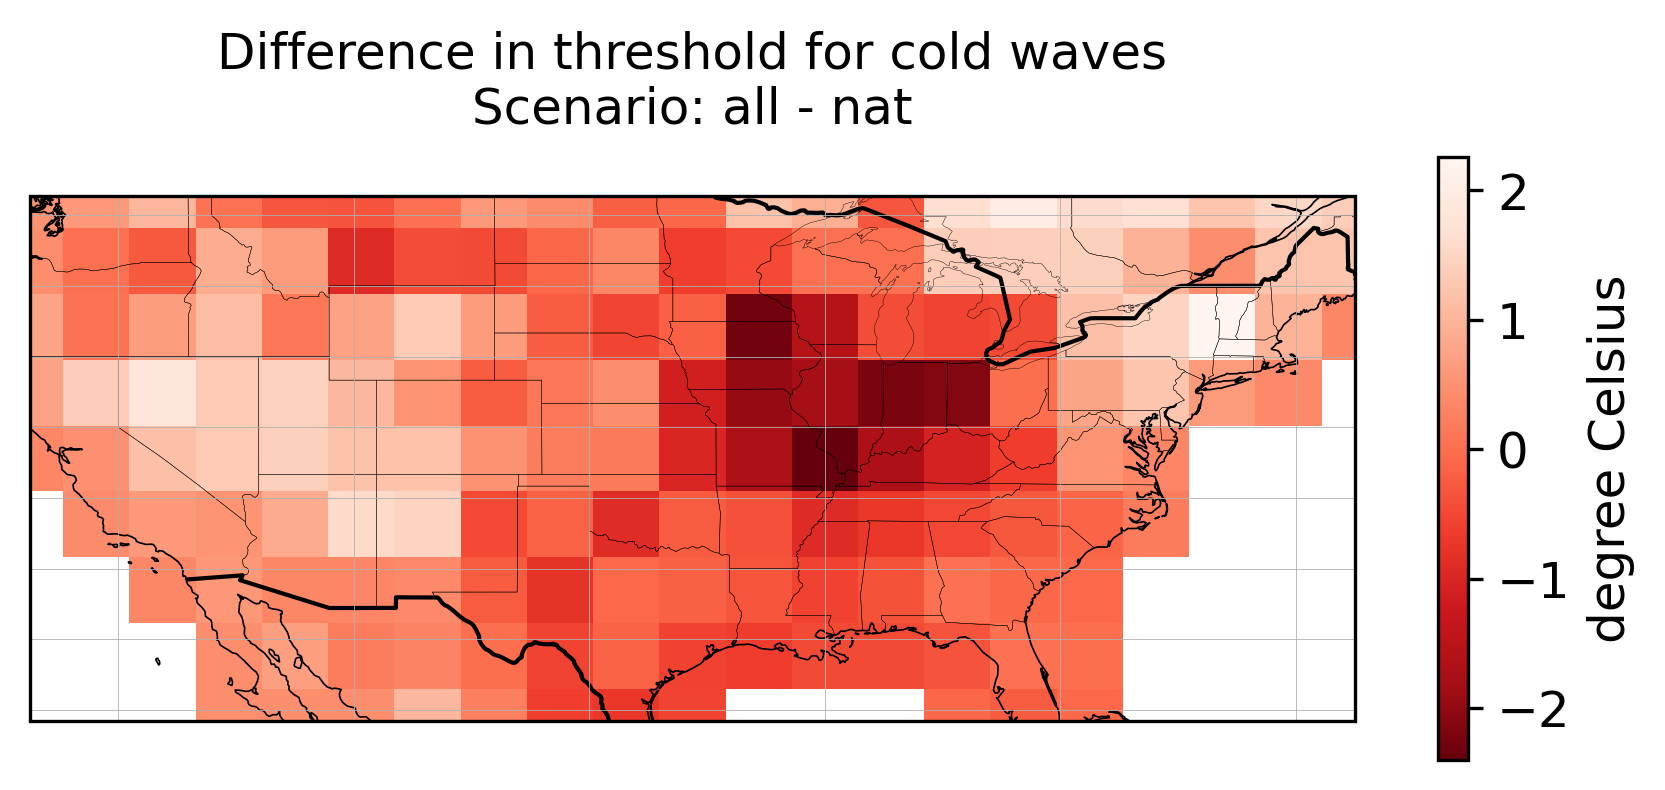

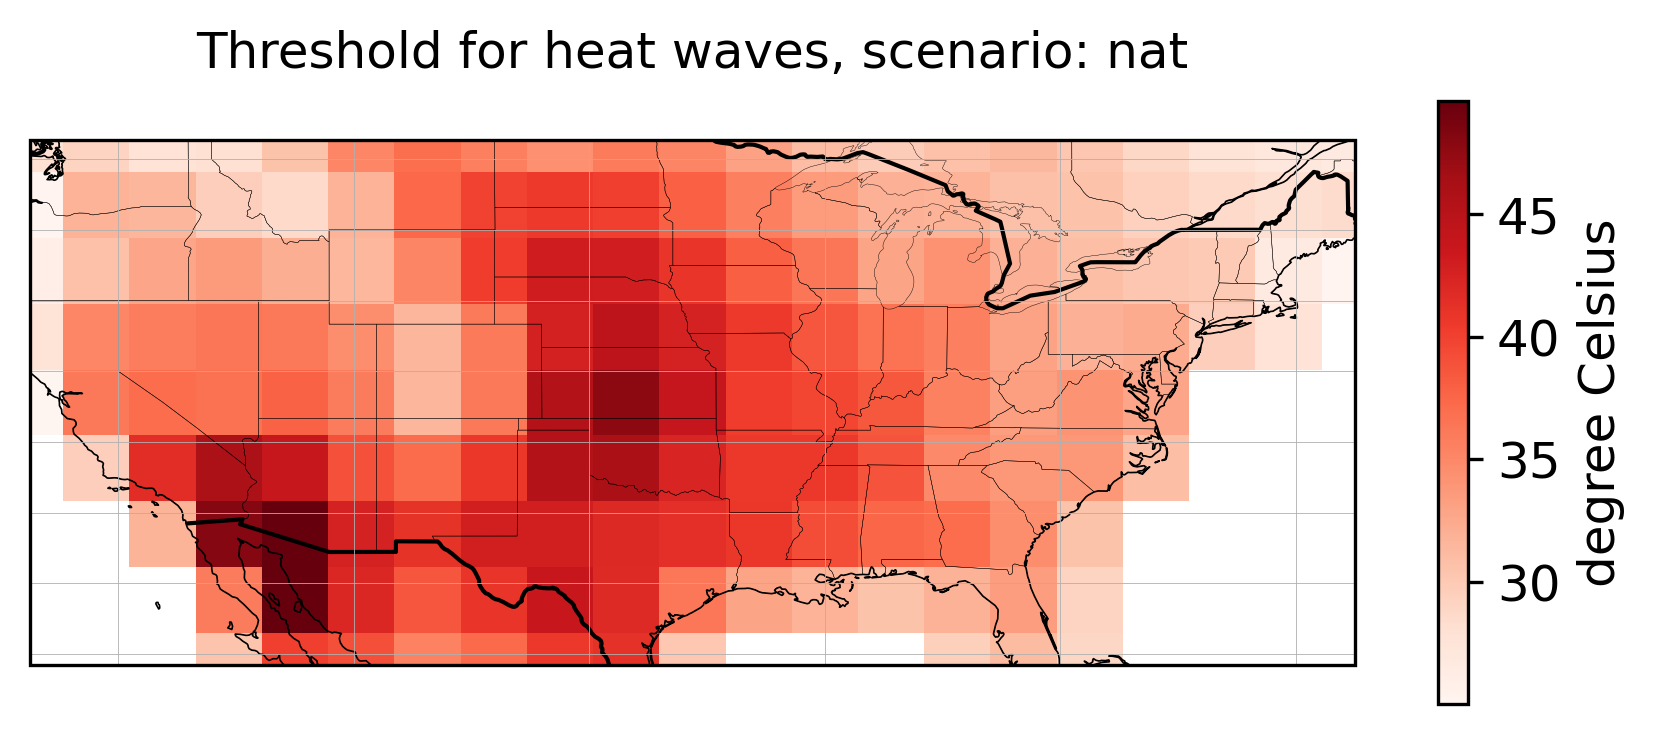

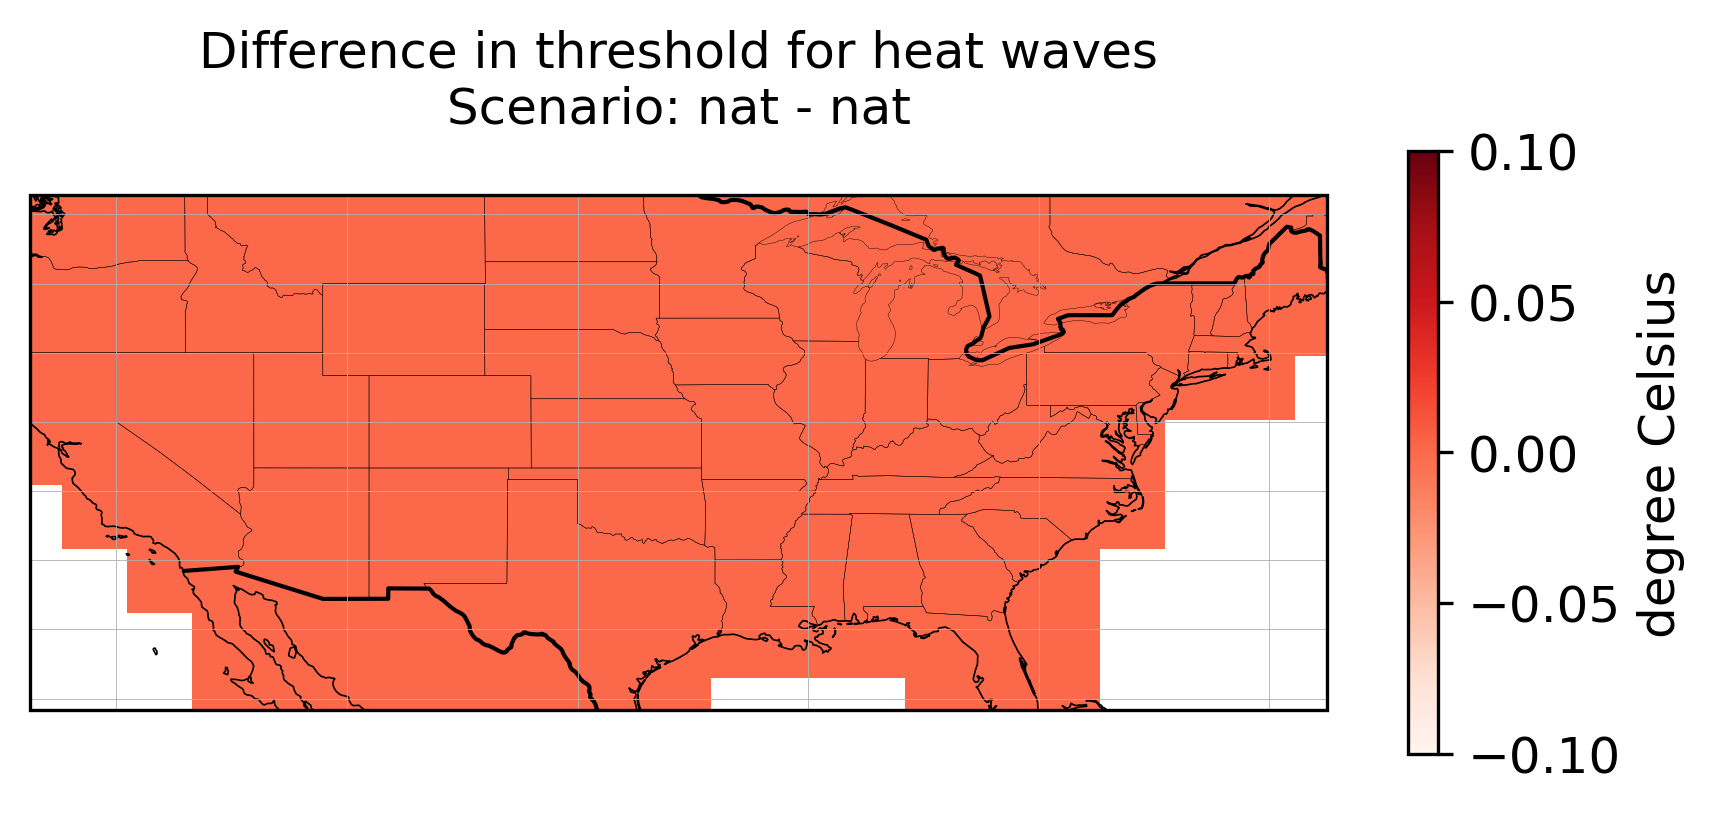

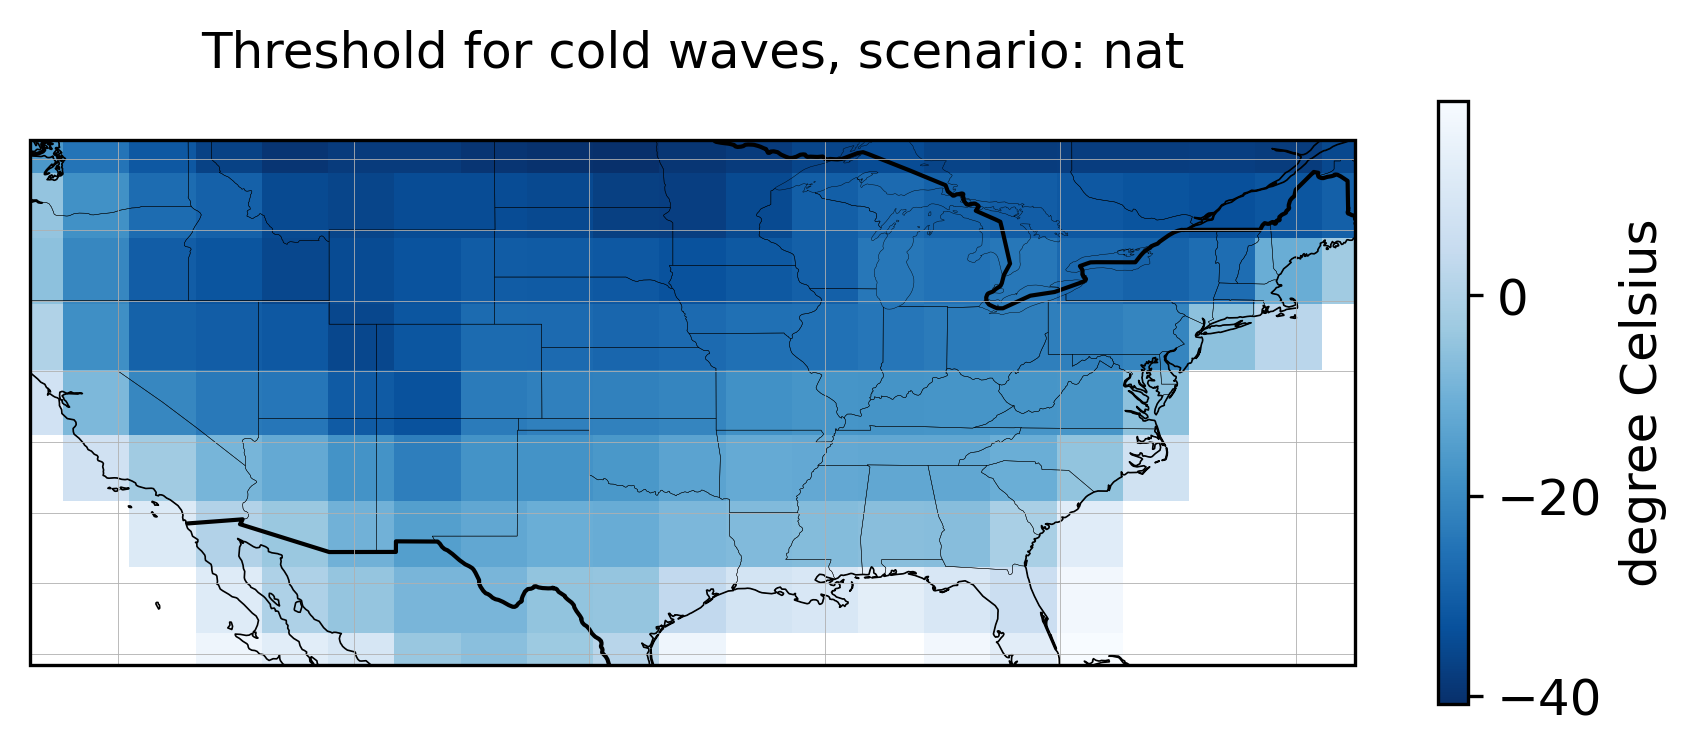

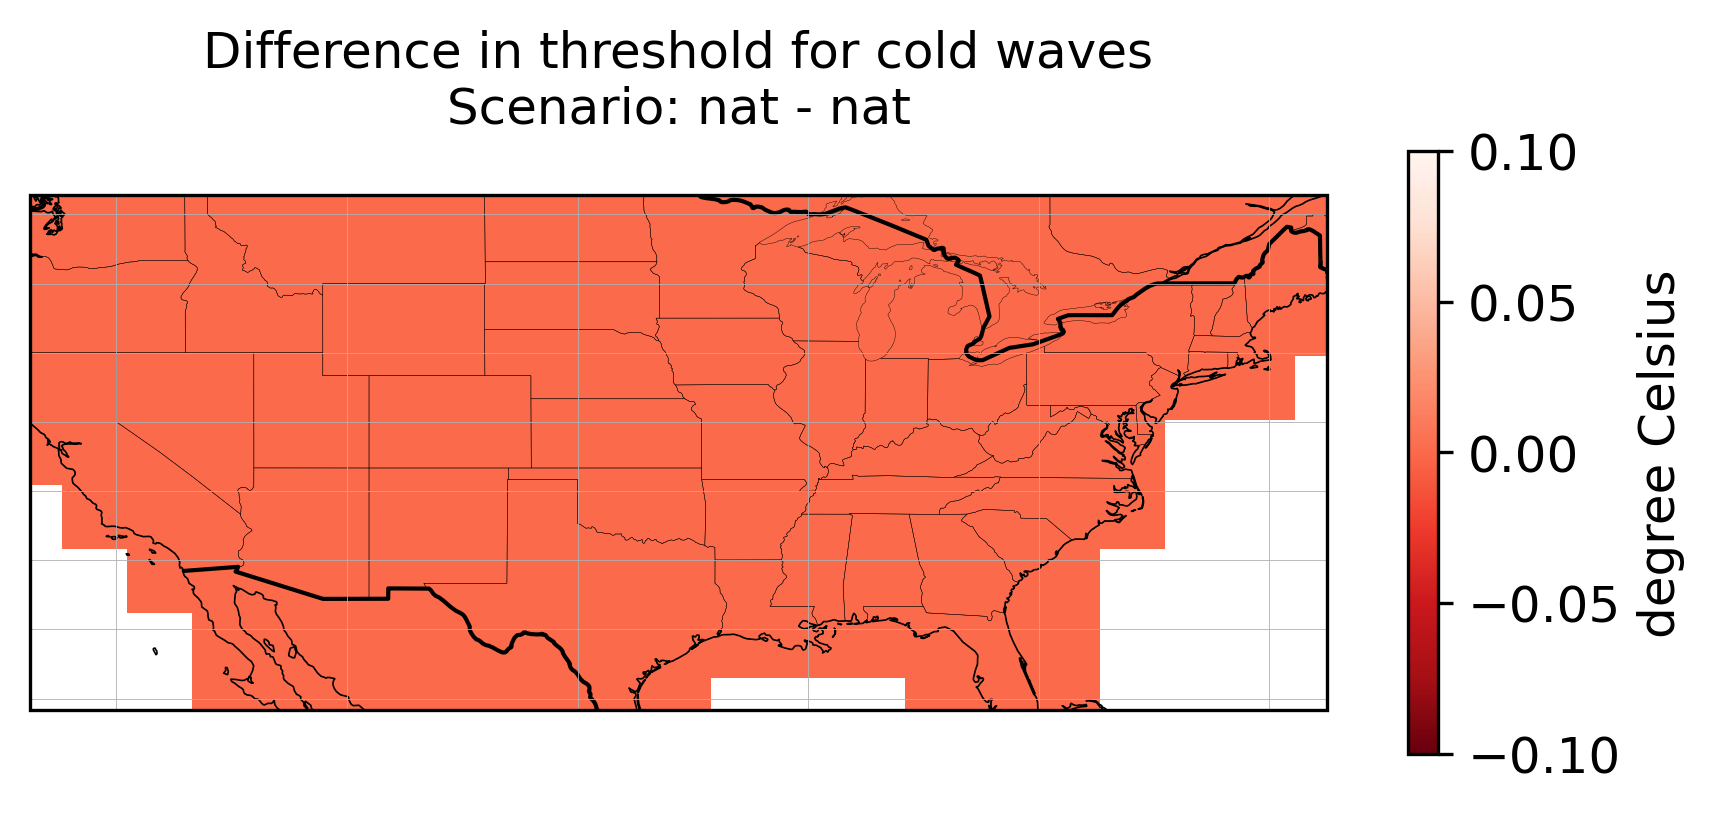

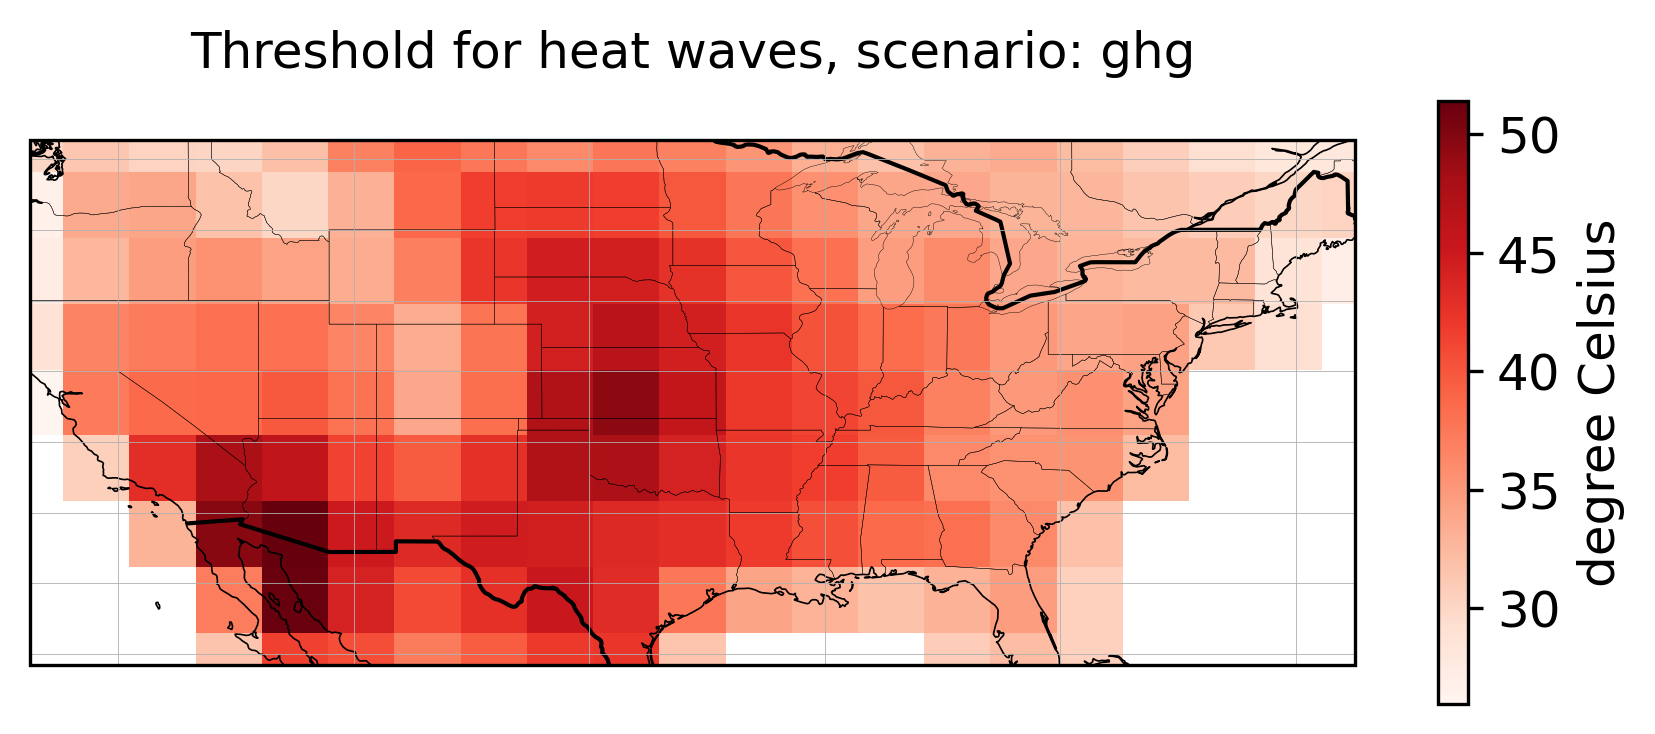

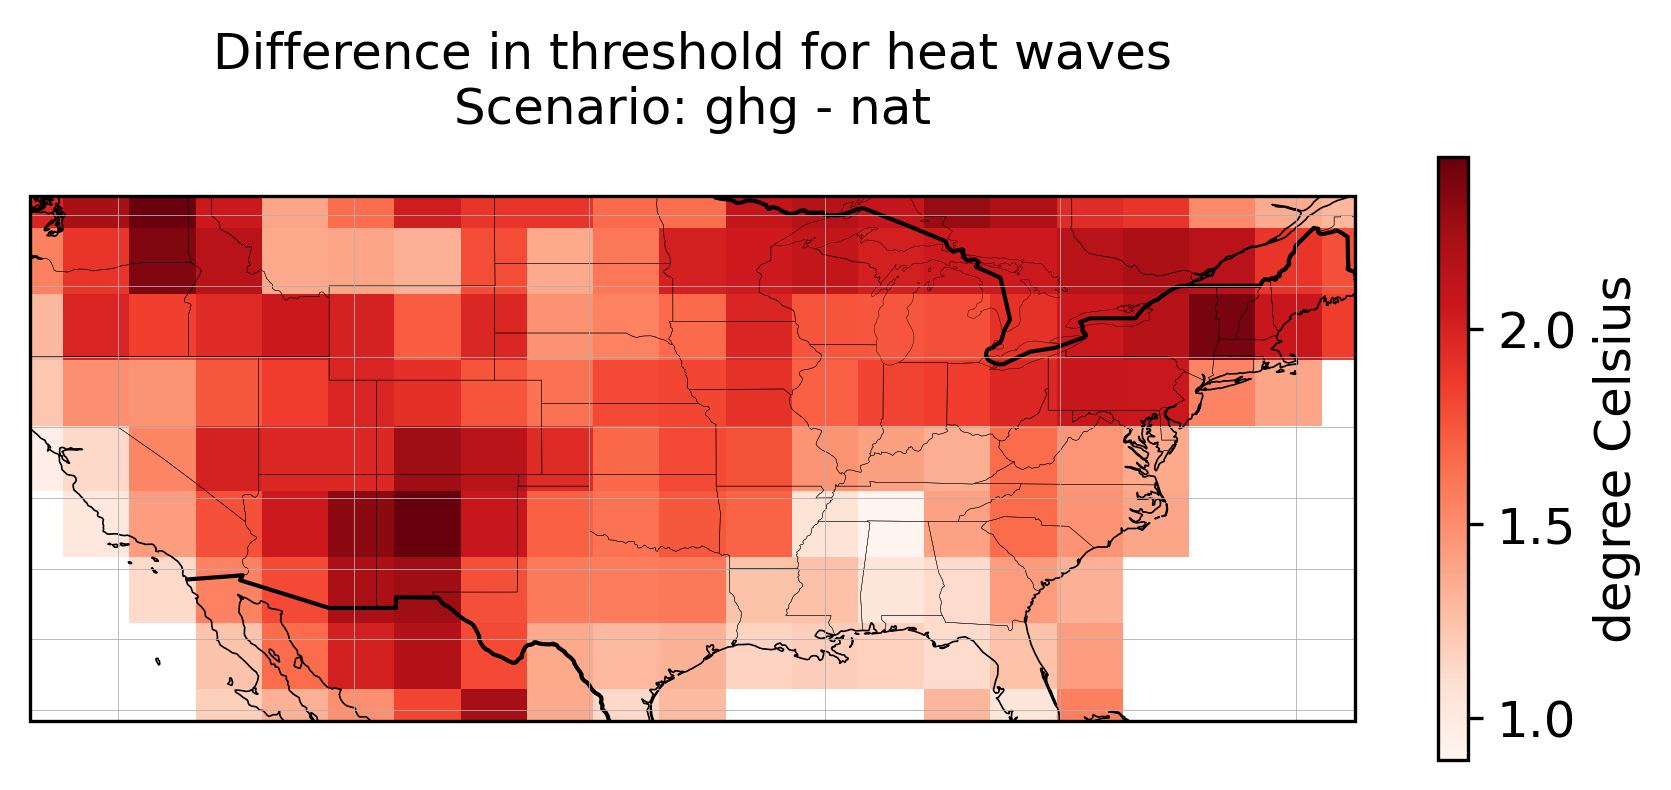

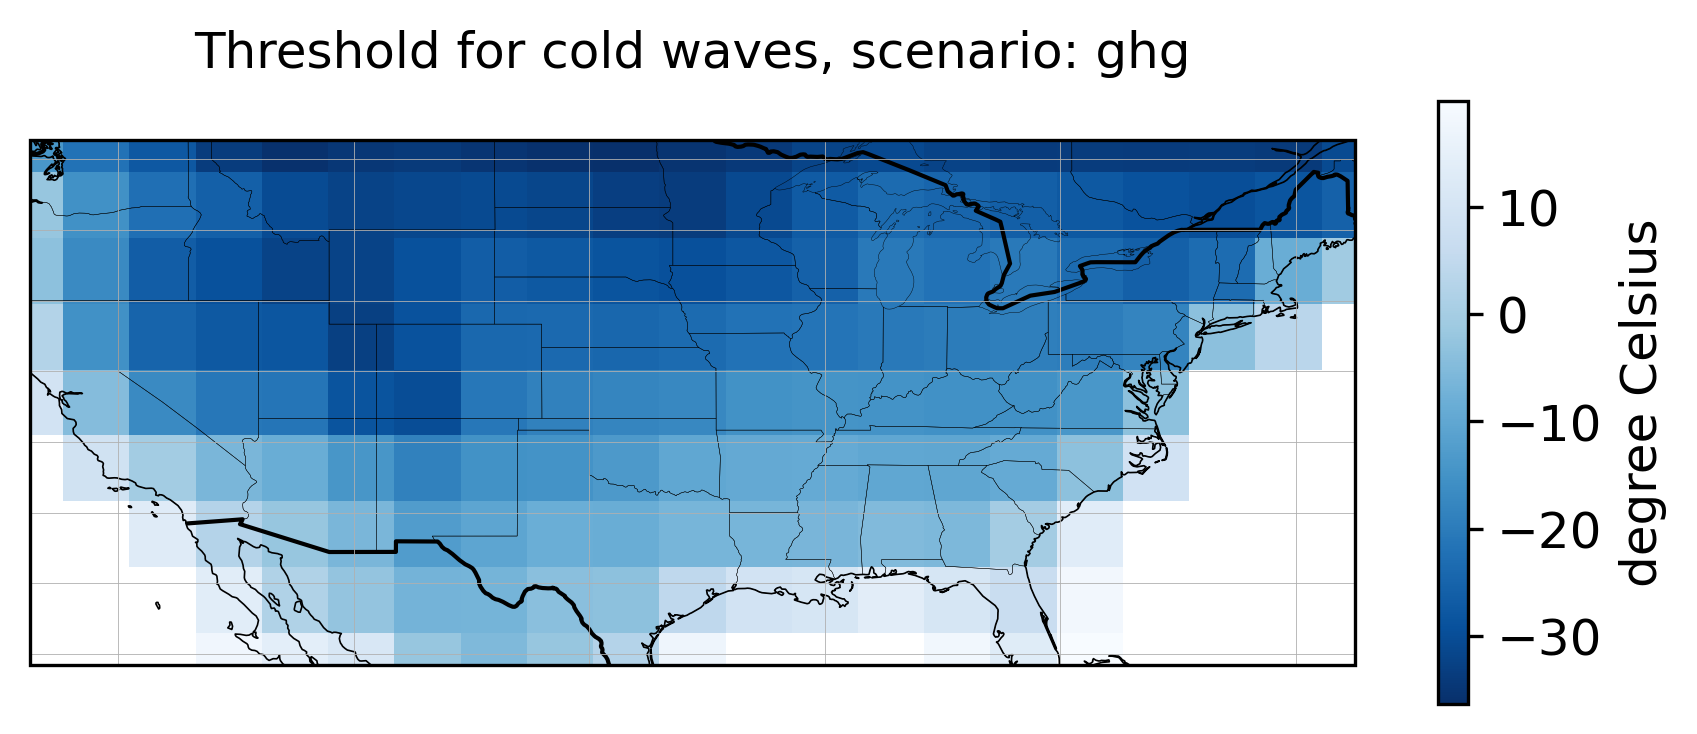

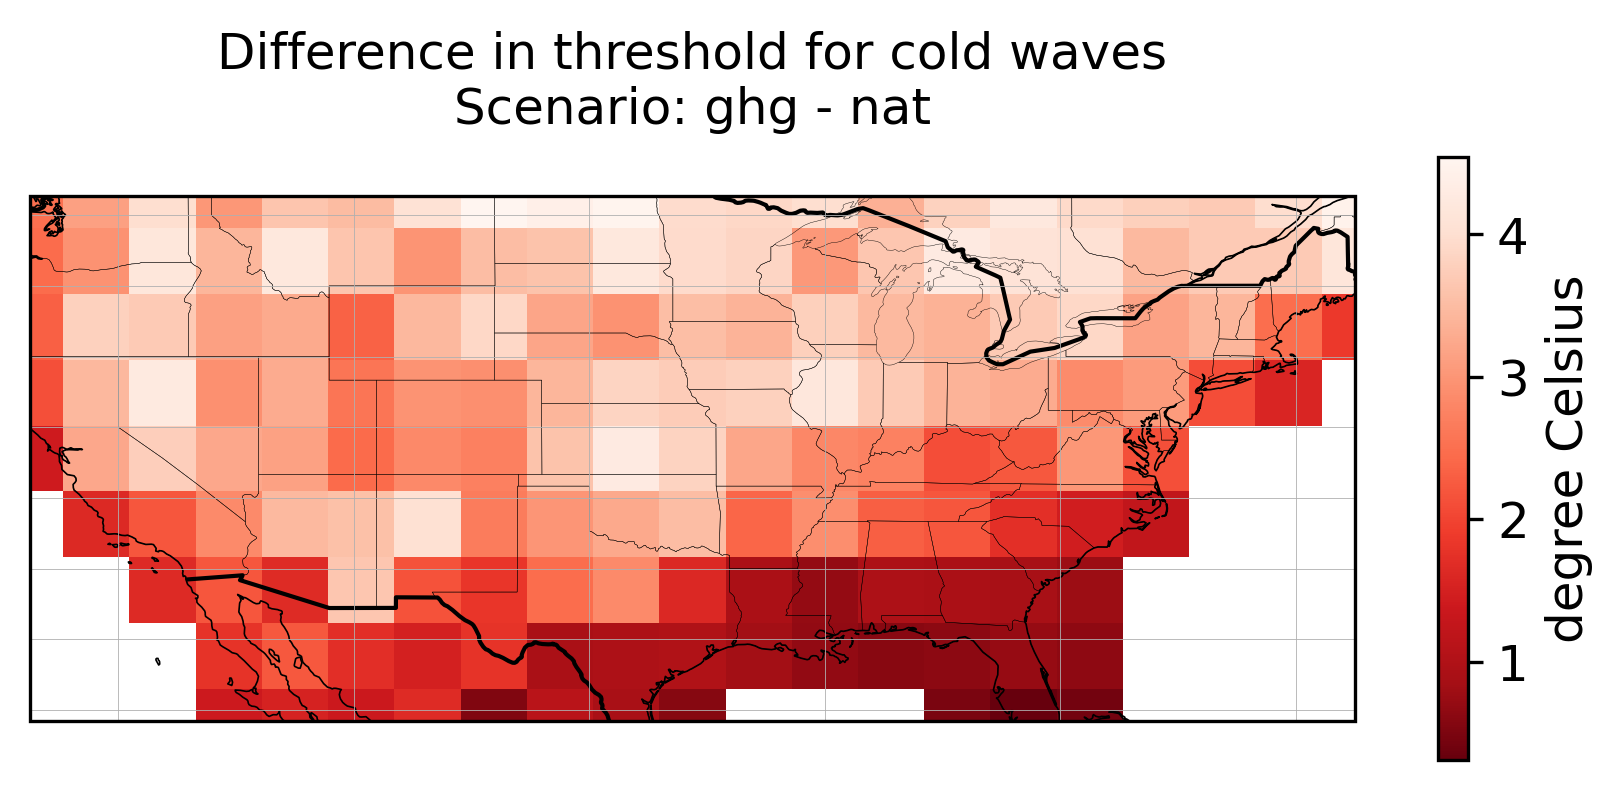

In [18]:
# Map from 'heat'/'cold' to label and colormaps
EXT_LABEL = {"heat": "heat waves", "cold": "cold waves"}
EXT_CMAP = {"heat": mpl.colormaps["Reds"], "cold": mpl.colormaps["Blues_r"]}
DIFF_CMAP = {"heat": mpl.colormaps["Reds"], "cold": mpl.colormaps["Reds_r"]}

# Smaller fonts to match your example
TITLE_FONTSIZE = 12
CBAR_LABELSIZE = 12
CBAR_TICKSIZE = 12
AX_TICKSIZE = 12

LON, LAT = np.meshgrid(lons_conus, lats_conus)



for sce in scenarios:
    for ext in temp_ext:
        label = EXT_LABEL[ext]

        # --- Threshold map ---
        fig, ax = plt.subplots(
            figsize=fig_size,
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        mesh = ax.pcolormesh(
            LON,
            LAT,
            th[ext]["grid"][sce],
            transform=ccrs.PlateCarree(),
            cmap=EXT_CMAP[ext],
            shading="nearest",
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        gl = ax.gridlines(draw_labels=False, linewidth=0.2)

        ax.tick_params(labelsize=AX_TICKSIZE)

        cbar = plt.colorbar(mesh, ax=ax, shrink=0.5)
        cbar.ax.set_ylabel("degree Celsius", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        ax.set_title(
            f"Threshold for {label}, scenario: {sce}\n",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"th_{ext}_{sce}.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

        # --- Difference map (scenario minus nat) ---
        fig, ax = plt.subplots(
            figsize=fig_size,
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        diff = th[ext]["grid"][sce] - th[ext]["grid"]["nat"]

        mesh = ax.pcolormesh(
            LON,
            LAT,
            diff,
            transform=ccrs.PlateCarree(),
            cmap=DIFF_CMAP[ext],
            shading="nearest",
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        gl = ax.gridlines(draw_labels=False, linewidth=0.2)

        ax.tick_params(labelsize=AX_TICKSIZE)

        cbar = plt.colorbar(mesh, ax=ax,shrink=0.5)
        cbar.ax.set_ylabel("degree Celsius", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        ax.set_title(
            f"Difference in threshold for {label}\nScenario: {sce} - nat\n",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"th_diff_{ext}_{sce}-nat.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

/global/homes/b/bharat/anaconda3/envs/pyces/lib/python3.9/site-packages/numpy/lib/function_base.py:4737: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/global/homes/b/bharat/anaconda3/envs/pyces/lib/python3.9/site-packages/numpy/lib/function_base.py:4737: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/global/homes/b/bharat/anaconda3/envs/pyces/lib/python3.9/site-packages/numpy/lib/function_base.py:4737: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/global/homes/b/bharat/anaconda3/envs/pyces/lib/python3.9/site-packages/numpy/lib/function_base.py:4737: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/global/homes/b/bharat/anaconda3/envs/pyces/lib/python3.9/site-packages/numpy/lib/function_base.py:4737: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/glob

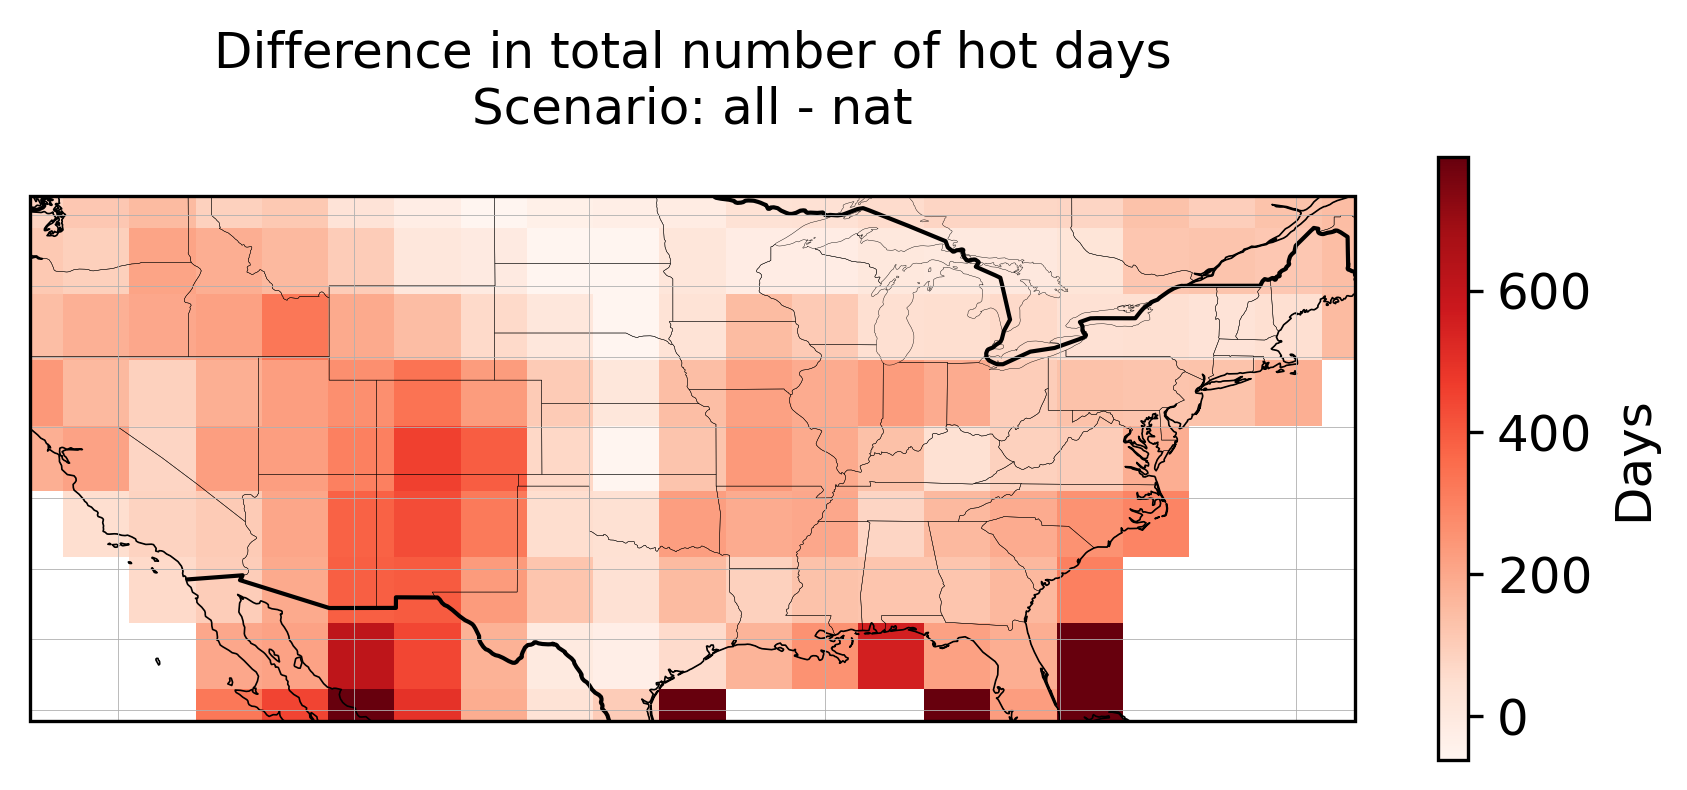

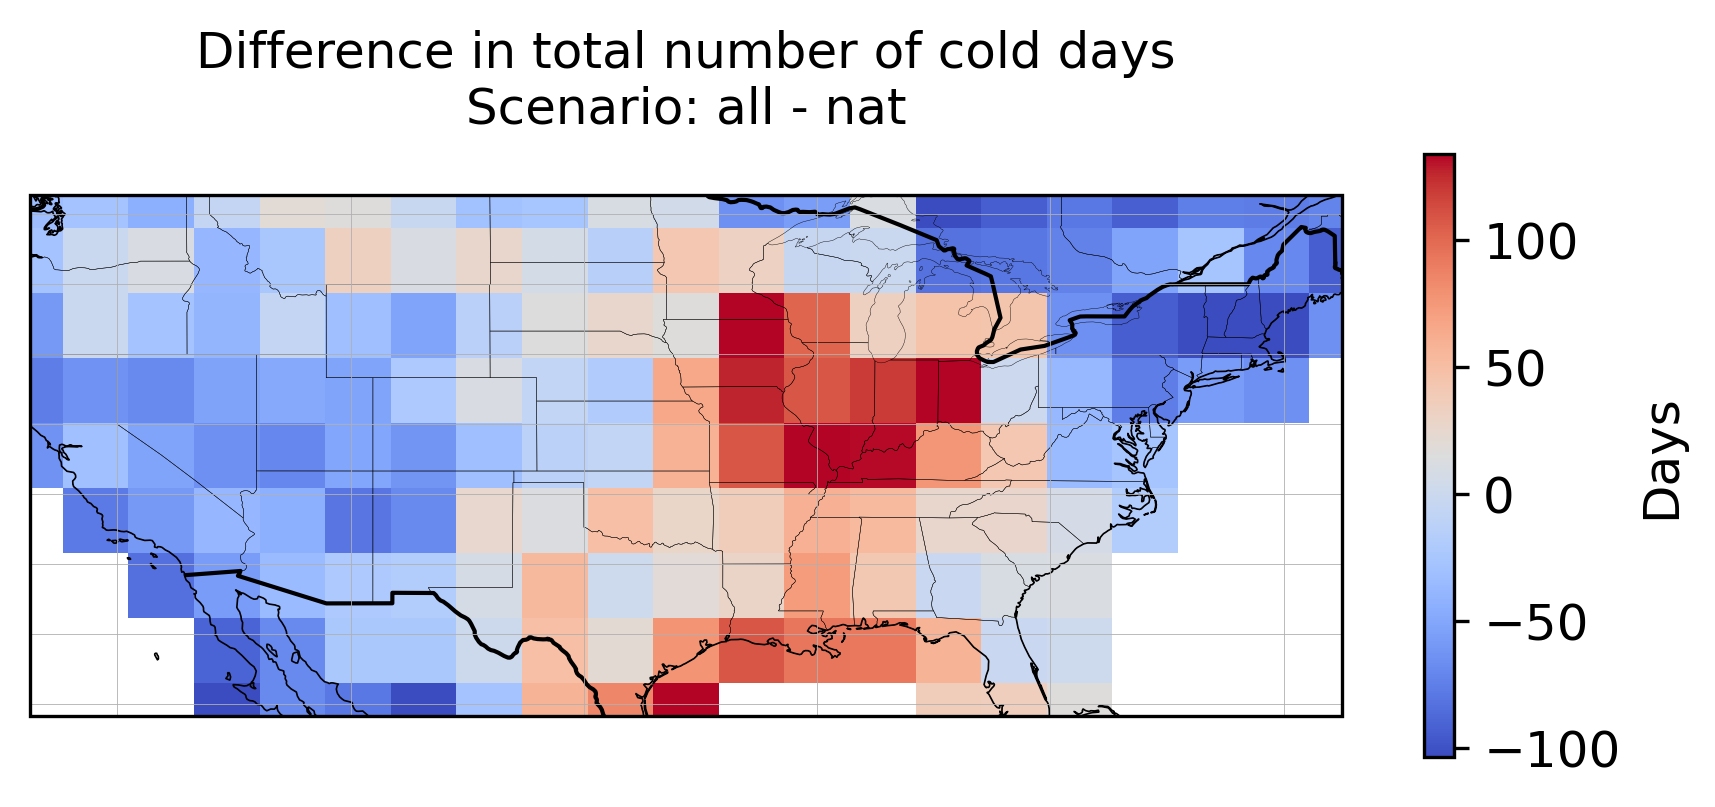

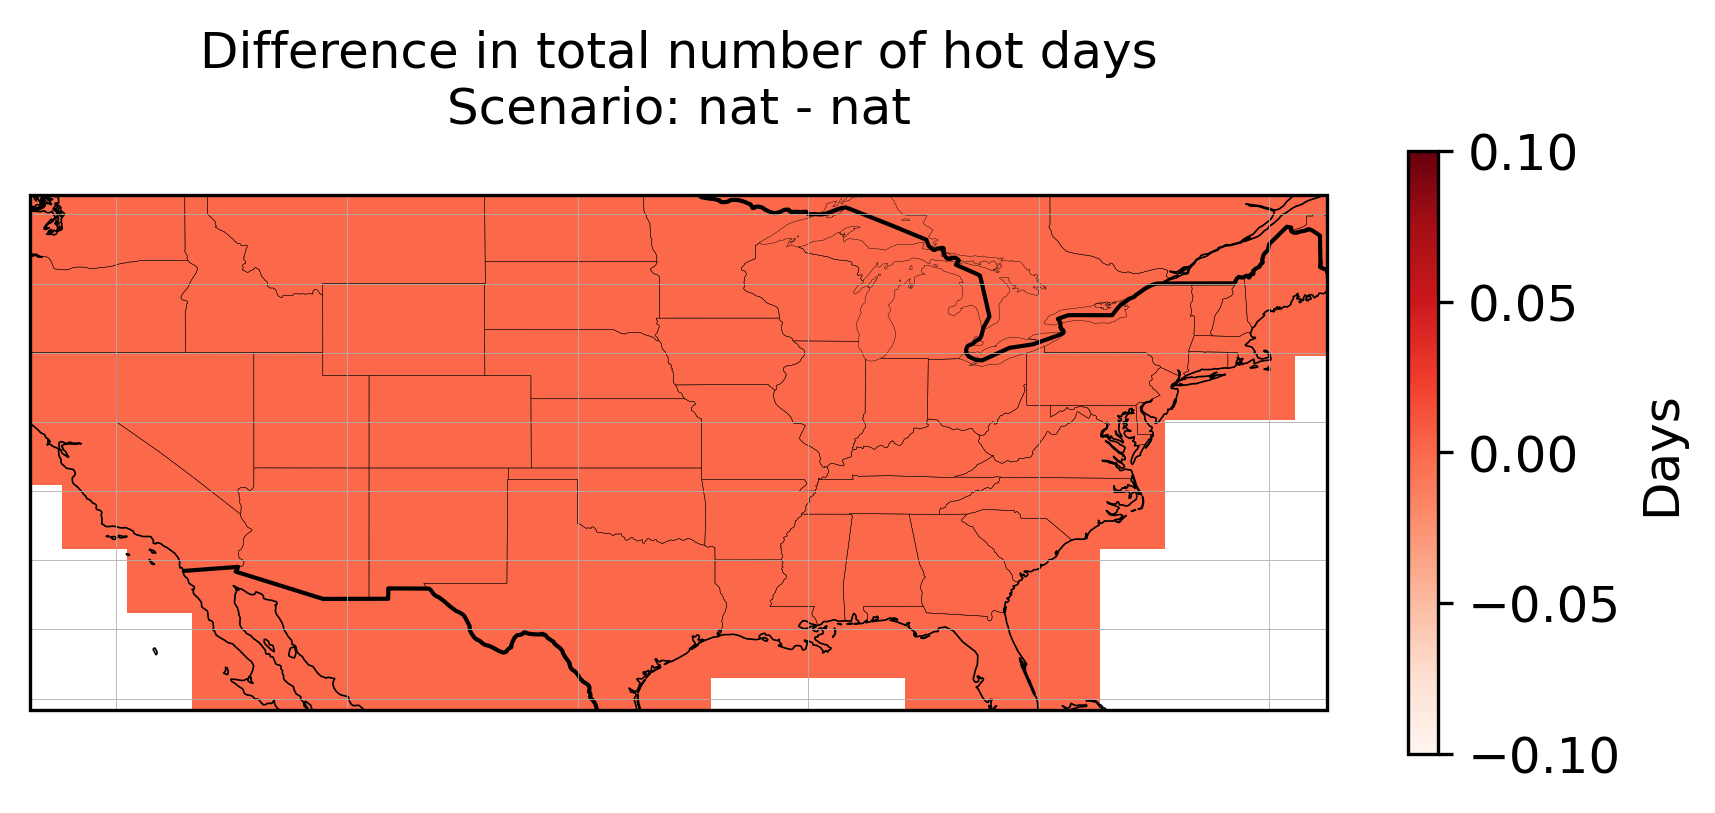

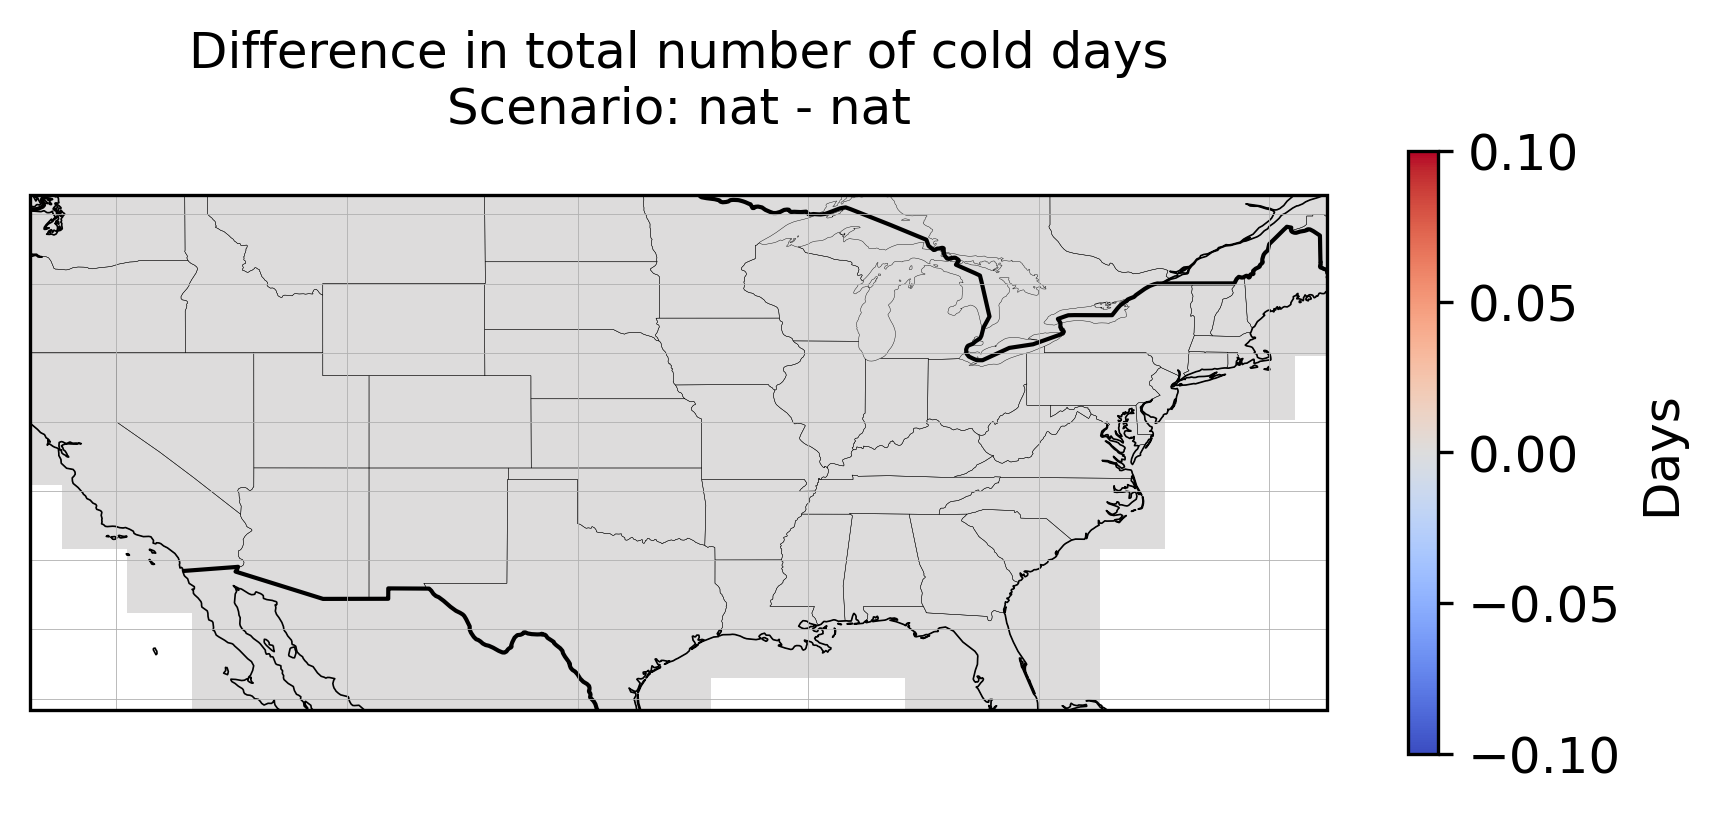

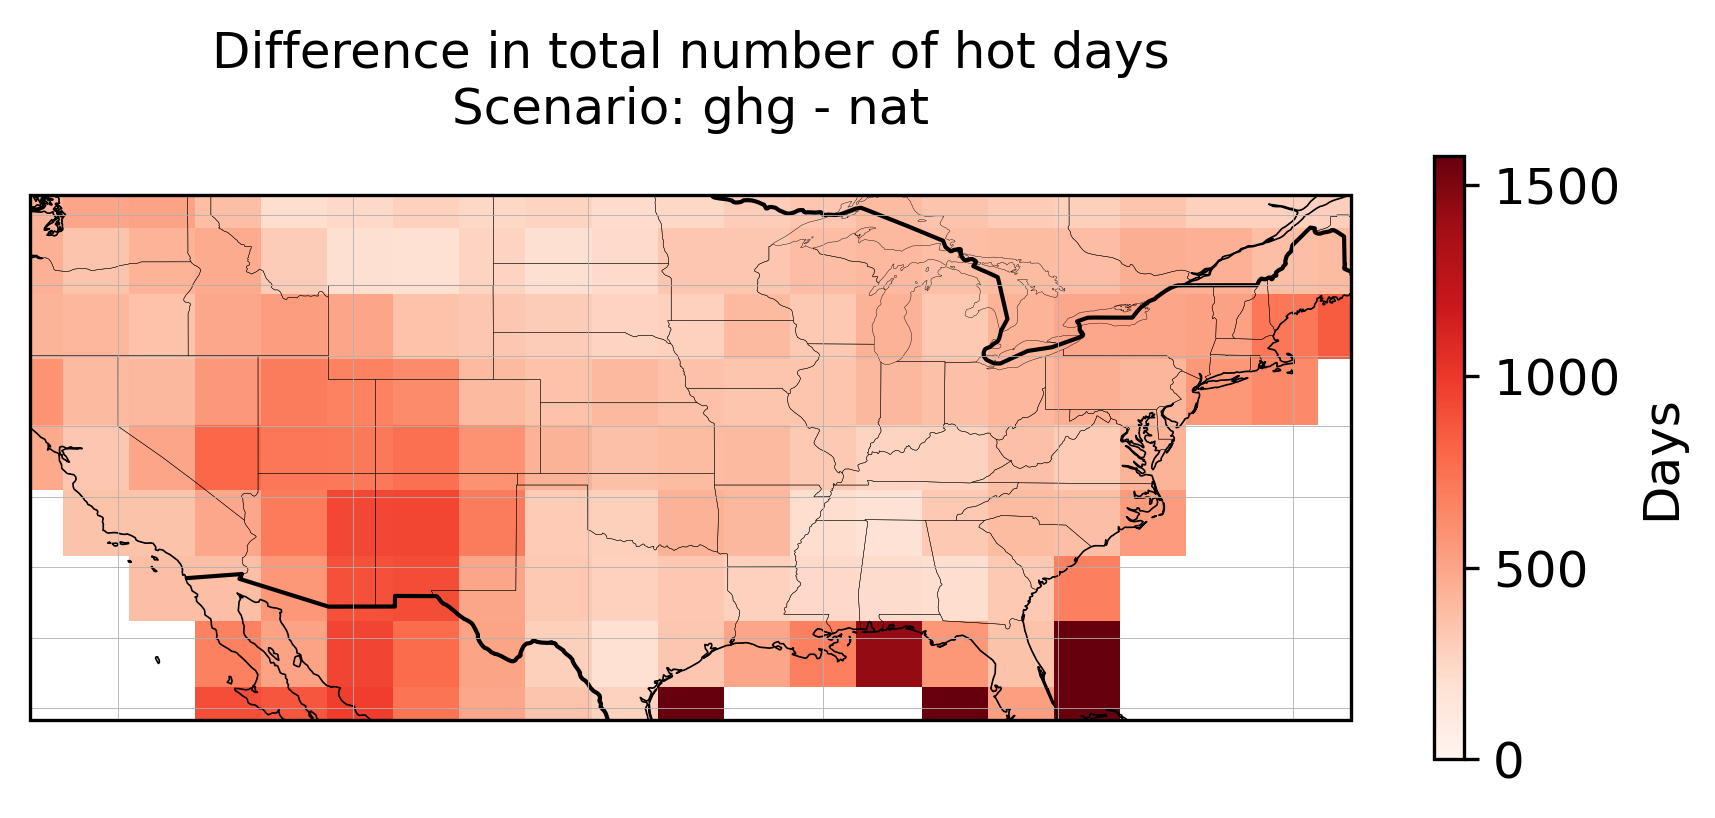

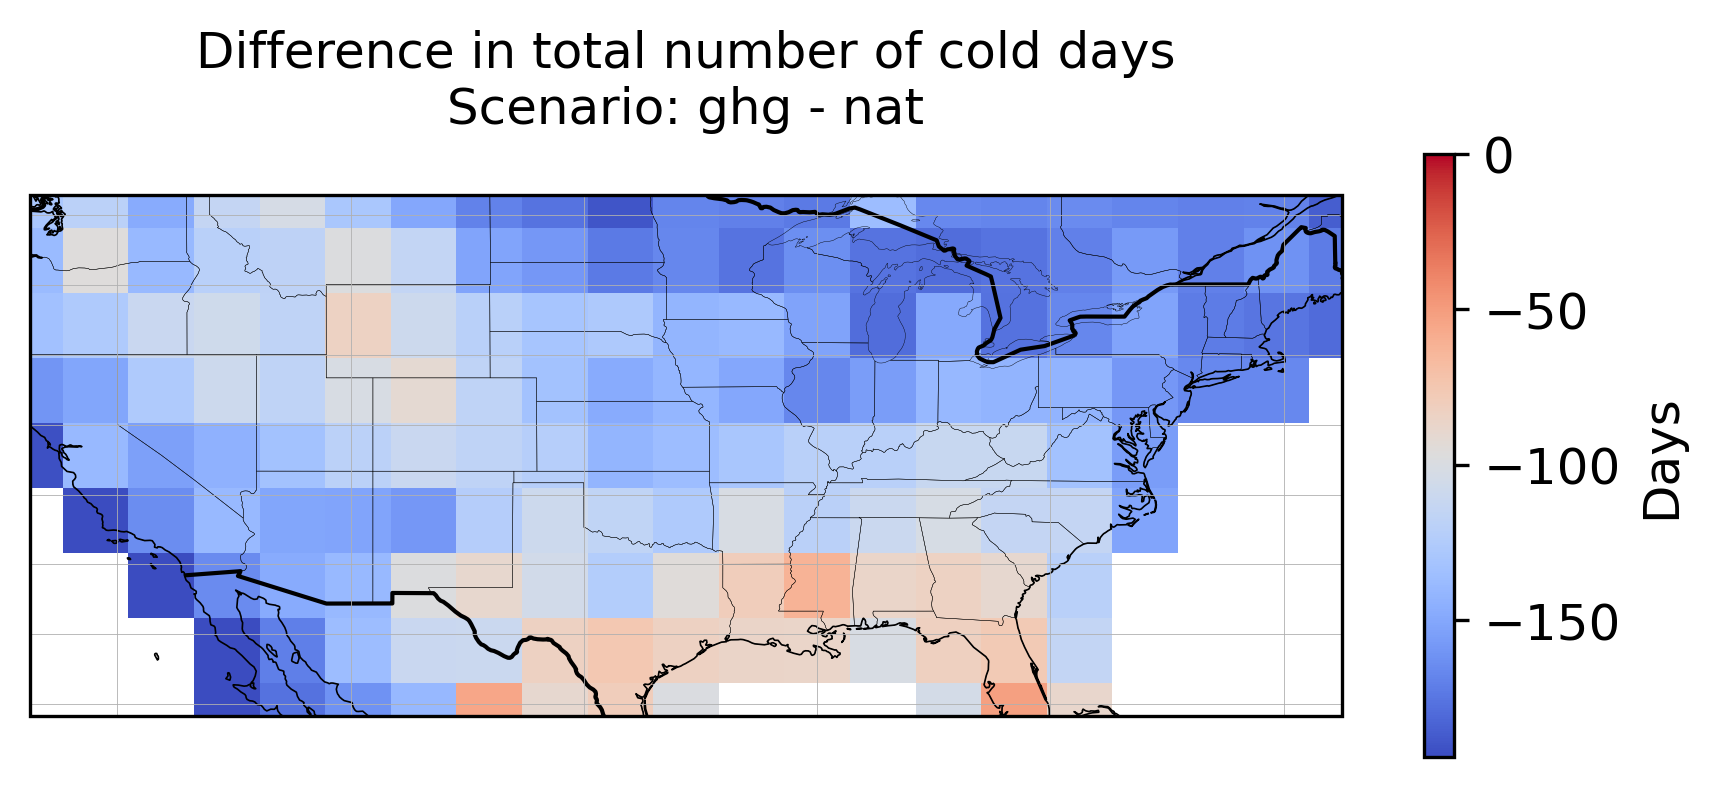

In [19]:

EXT_LABEL = {"heat": "hot", "cold": "cold"}
EXT_CMAP_TOTAL_DIFF = {
    "heat": mpl.colormaps["Reds"],
    "cold": mpl.colormaps["coolwarm"],
}

LON, LAT = np.meshgrid(lons_conus, lats_conus)

# Spatial map of total increase in hot/cold days (scenario vs nat)
for sce in scenarios:
    for ext in temp_ext:
        label = EXT_LABEL[ext]

        # Sum over years → total days per grid cell
        total_sce = np.sum(th[ext]["hdays_py"][sce], axis=0)     # (lat, lon)
        total_nat = np.sum(th[ext]["hdays_py"]["nat"], axis=0)   # (lat, lon)
        diff_days = total_sce - total_nat

        data = diff_days#.filled(np.nan)
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)

        fig, ax = plt.subplots(
            figsize=fig_size,
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},

        )

        mesh = ax.pcolormesh(
            LON,
            LAT,
            diff_days,
            transform=ccrs.PlateCarree(),
            cmap=EXT_CMAP_TOTAL_DIFF[ext],
            shading="nearest",
                        vmin=vmin,
            vmax=vmax,
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        ax.gridlines(draw_labels=False, linewidth=0.2)

        # Axis ticks
        ax.tick_params(labelsize=AX_TICKSIZE)

        # Colorbar
        cbar = plt.colorbar(mesh, ax=ax, shrink=0.5)
        cbar.ax.set_ylabel("Days", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        # Title
        ax.set_title(
            f"Difference in total number of {label} days\nScenario: {sce} - nat\n",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"diff_{ext}_days_{sce}-nat.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

In [33]:
start_date

'1950-01-01'

In [34]:
if isinstance(start_date, str):
    start_year = int(start_date[:4])
    start_month = int(start_date[5:7])
    start_day = int(start_date[8:10])
else:
    start_month = start_date.month
    start_day = start_date.day

yrs_dt = [cftime.DatetimeNoLeap(int(yr), start_month, start_day) for yr in yrs]

In [35]:
th["heat"]["days_pr_stats"] = {}
th["cold"]["days_pr_stats"] = {}

for sce in scenarios:
    th["heat"]["days_pr_stats"][sce] = {}
    th["cold"]["days_pr_stats"][sce] = {}

    # Heat
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(
        yrs, th["heat"]["day_comp"][sce][:, 1]
    )
    th["heat"]["days_pr_stats"][sce]["slope"] = slope
    th["heat"]["days_pr_stats"][sce]["intercept"] = intercept
    th["heat"]["days_pr_stats"][sce]["rvalue"] = rvalue
    th["heat"]["days_pr_stats"][sce]["pvalue"] = pvalue
    th["heat"]["days_pr_stats"][sce]["stderr"] = stderr
    th["heat"]["days_pr_stats"][sce]["trend"] = slope * np.asarray(yrs) + intercept

    # Cold
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(
        yrs, th["cold"]["day_comp"][sce][:, 1]
    )
    th["cold"]["days_pr_stats"][sce]["slope"] = slope
    th["cold"]["days_pr_stats"][sce]["intercept"] = intercept
    th["cold"]["days_pr_stats"][sce]["rvalue"] = rvalue
    th["cold"]["days_pr_stats"][sce]["pvalue"] = pvalue
    th["cold"]["days_pr_stats"][sce]["stderr"] = stderr
    th["cold"]["days_pr_stats"][sce]["trend"] = slope * np.asarray(yrs) + intercept


In [36]:

title_fs = 10
label_fs = 10
tick_fs = 8
legend_fs = 8
line_fs = 0.7
trend_fs = 0.5

colors = {
    "nat": "b",
    "ghg": "k",
    "all": "r",
}

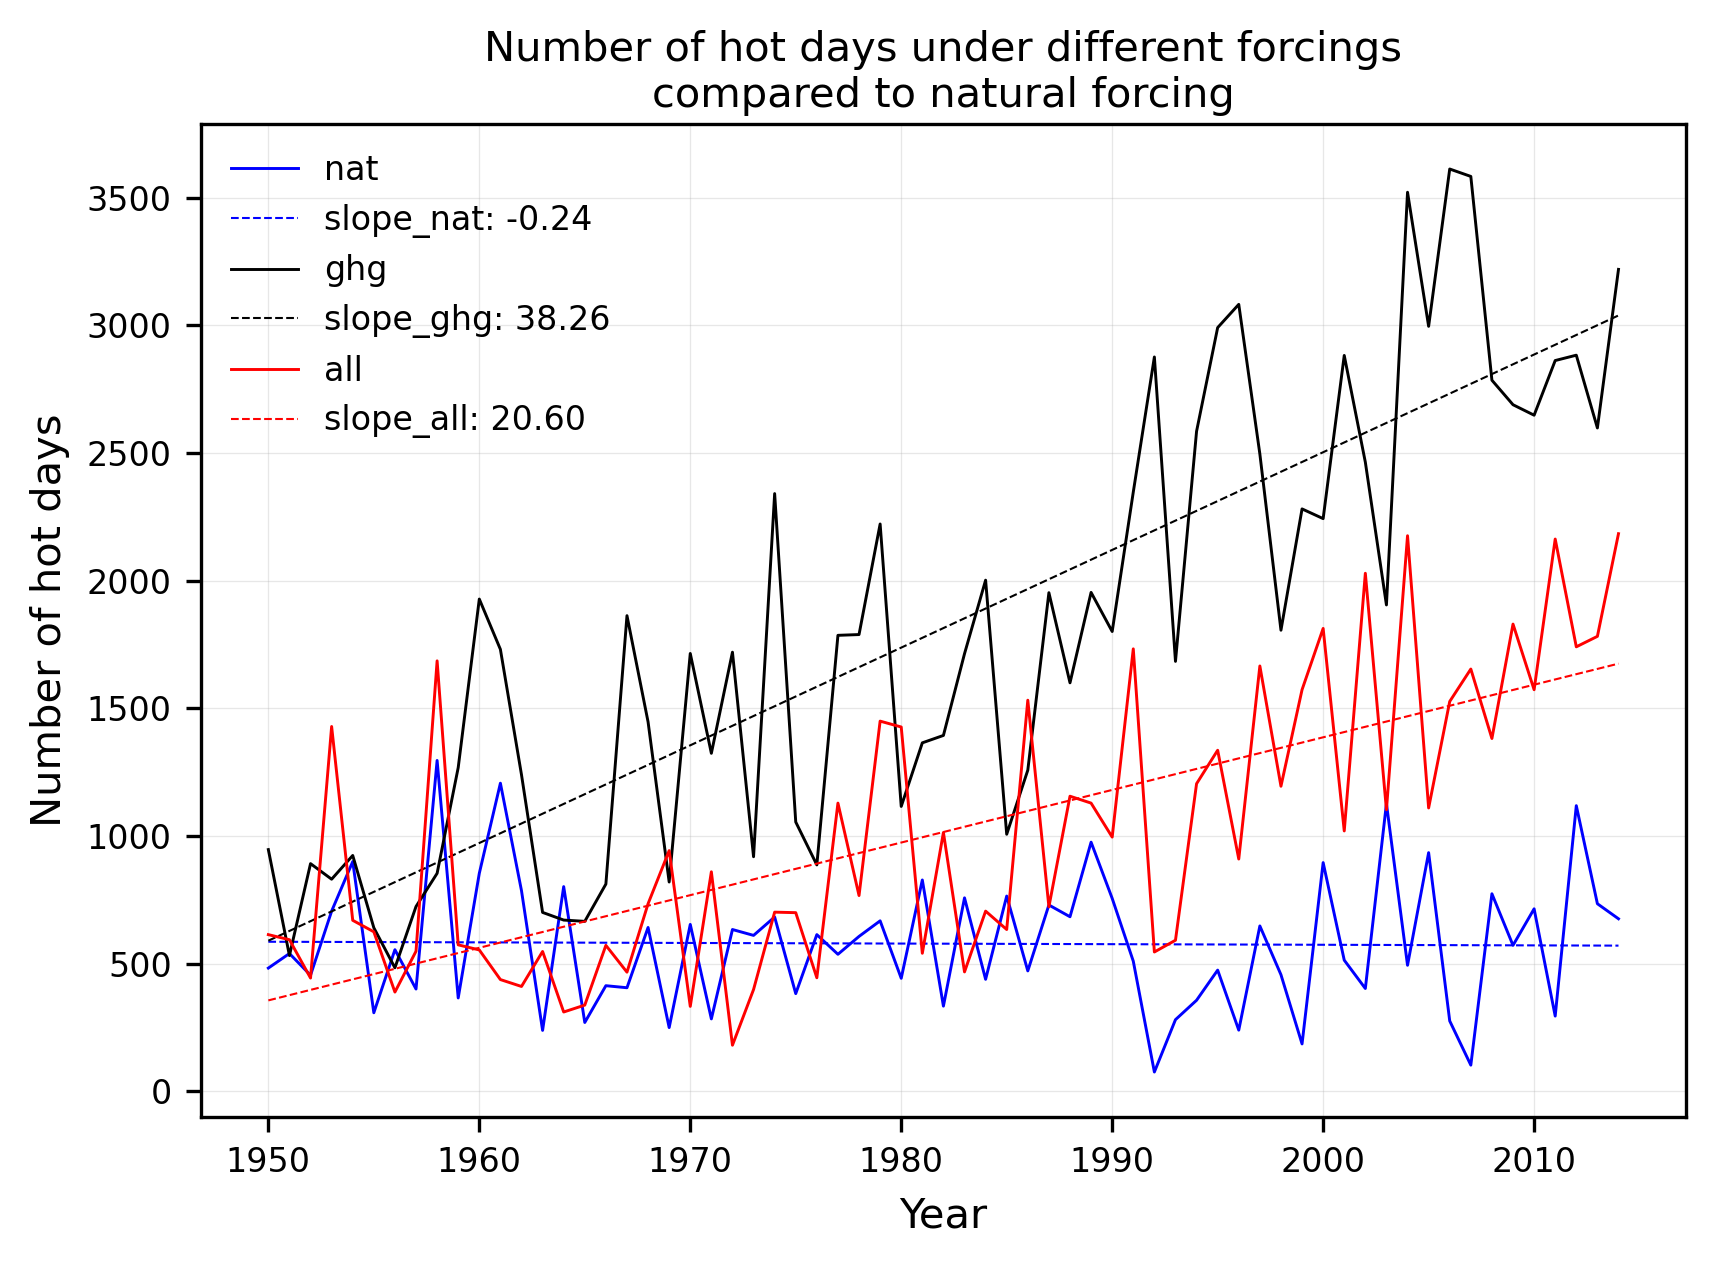

In [37]:
fig, ax = plt.subplots(figsize=fig_size, dpi=300, tight_layout=True)

for sce in ["nat", "ghg", "all"]:
    ax.plot(
        yrs,
        th["heat"]["day_comp"][sce][:, 1],
        color=colors[sce],
        linewidth=line_fs,
        label=sce,
    )
    ax.plot(
        yrs,
        th["heat"]["days_pr_stats"][sce]["trend"],
        linestyle="--",
        color=colors[sce],
        linewidth=trend_fs,
        label=f"slope_{sce}: {th['heat']['days_pr_stats'][sce]['slope']:.2f}",
    )

ax.set_title(
    "Number of hot days under different forcings\ncompared to natural forcing",
    fontsize=title_fs,
    pad=4,
)
ax.set_xlabel("Year", fontsize=label_fs)
ax.set_ylabel("Number of hot days", fontsize=label_fs)
ax.tick_params(axis="both", labelsize=tick_fs)
ax.legend(fontsize=legend_fs, frameon=False)
ax.grid(alpha=0.3, linewidth=0.3)

fig.savefig(os.path.join(out_path, "hot_days_py.png"), bbox_inches="tight")
#plt.close(fig)


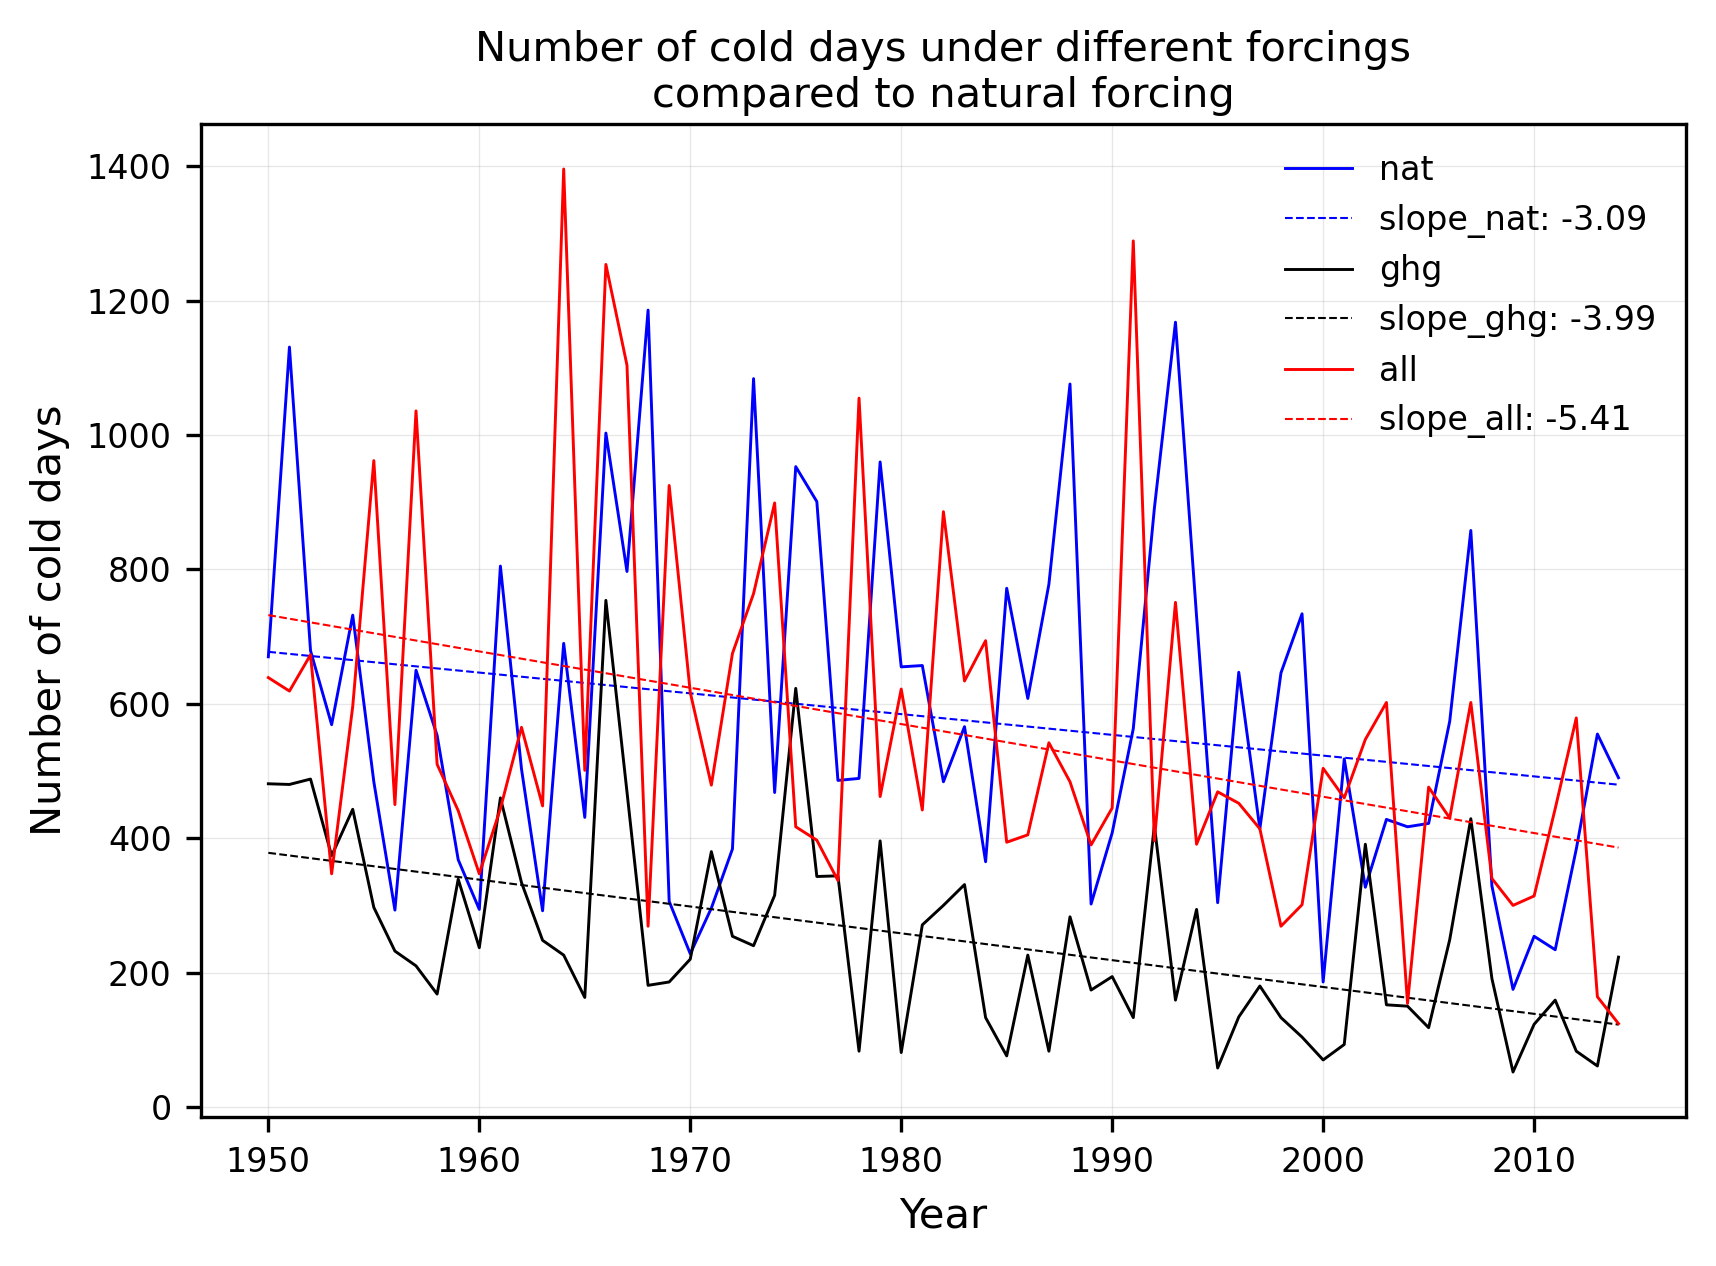

In [38]:
fig, ax = plt.subplots(figsize=fig_size, dpi=300, tight_layout=True)

for sce in ["nat", "ghg", "all"]:
    ax.plot(
        yrs,
        th["cold"]["day_comp"][sce][:, 1],
        color=colors[sce],
        linewidth=line_fs,
        label=sce,
    )
    ax.plot(
        yrs,
        th["cold"]["days_pr_stats"][sce]["trend"],
        linestyle="--",
        color=colors[sce],
        linewidth=trend_fs,
        label=f"slope_{sce}: {th['cold']['days_pr_stats'][sce]['slope']:.2f}",
    )

ax.set_title(
    "Number of cold days under different forcings\ncompared to natural forcing",
    fontsize=title_fs,
    pad=4,
)
ax.set_xlabel("Year", fontsize=label_fs)
ax.set_ylabel("Number of cold days", fontsize=label_fs)
ax.tick_params(axis="both", labelsize=tick_fs)
ax.legend(fontsize=legend_fs, frameon=False)
ax.grid(alpha=0.3, linewidth=0.3)

fig.savefig(os.path.join(out_path, "cold_days_py.png"), bbox_inches="tight")
#plt.close(fig)

In [39]:
for sce in scenarios:
    for ext in temp_ext:
        print(
            "pvalue_%s_%s :" % (sce, ext),
            th[ext]["days_pr_stats"][sce]["pvalue"],
            "rvalue_%s_%s :" % (sce, ext),
            th[ext]["days_pr_stats"][sce]["rvalue"],
        )


# Hot days <e>

# Heat waves using ndimage <b>
th["heat"]["waves"] = {}
th["cold"]["waves"] = {}
str_hw = np.ones((3))

for sce in scenarios:
    for ext in temp_ext:
        tmp_3d_ar = np.ma.masked_equal(
            np.zeros((len(yrs), ocean_mask_conus.mask.shape[0], ocean_mask_conus.mask.shape[1])), 0
        )
        for idx, yr in enumerate(yrs):
            for idx_lat in range(ocean_mask_conus.mask.shape[0]):
                for idx_lon in range(ocean_mask_conus.mask.shape[1]):
                    tmp_ar = th[ext]["comp"][sce][(idx + 1) * 365 - 365 : (idx + 1) * 365, idx_lat, idx_lon]
                    # labeling all the continuous extreme events
                    larray, narray = ndimage.label(tmp_ar, structure=str_hw)
                    if narray > 0:
                        # identifying the locations of the blobs
                        locations = ndimage.find_objects(larray)
                        hw_count = []
                        for loc in locations:
                            consec_days = np.sum(tmp_ar[loc])
                            if consec_days > 5:
                                hw_count.append(1)
                        hw_count = np.array(hw_count)
                    else:
                        hw_count = np.array([0])
                    tmp_3d_ar[idx, idx_lat, idx_lon] = np.sum(hw_count)
        th[ext]["waves"][sce] = tmp_3d_ar.copy()

th["heat"]["slope_pp"] = {}
th["cold"]["slope_pp"] = {}

for sce in scenarios:
    for ext in temp_ext:
        slope_pp_hw = np.ma.masked_equal(np.zeros((ocean_mask_conus.mask.shape[0], ocean_mask_conus.mask.shape[1])), 0)
        for idx, yr in enumerate(yrs):
            for idx_lat in range(ocean_mask_conus.mask.shape[0]):
                for idx_lon in range(ocean_mask_conus.mask.shape[1]):
                    tmp_ar = th[ext]["waves"][sce][:, idx_lat, idx_lon]
                    m, c, _, _, _ = stats.linregress(yrs, tmp_ar)
                    slope_pp_hw[idx_lat, idx_lon] = m * 100
        th[ext]["slope_pp"][sce] = np.ma.array(slope_pp_hw, mask=ocean_mask_conus.mask)  # Slope in percentage per pixel

pvalue_all_heat : 2.8151976593788476e-11 rvalue_all_heat : 0.7124613286427418
pvalue_all_cold : 0.001709214706546237 rvalue_all_cold : -0.38161418891333143
pvalue_nat_heat : 0.8926335989873293 rvalue_nat_heat : -0.01707130502242076
pvalue_nat_cold : 0.07093835387984646 rvalue_nat_cold : -0.22547178268165435
pvalue_ghg_heat : 1.3554906191375022e-18 rvalue_ghg_heat : 0.842685827866005
pvalue_ghg_cold : 1.1086154535263335e-05 rvalue_ghg_cold : -0.5155470323702412


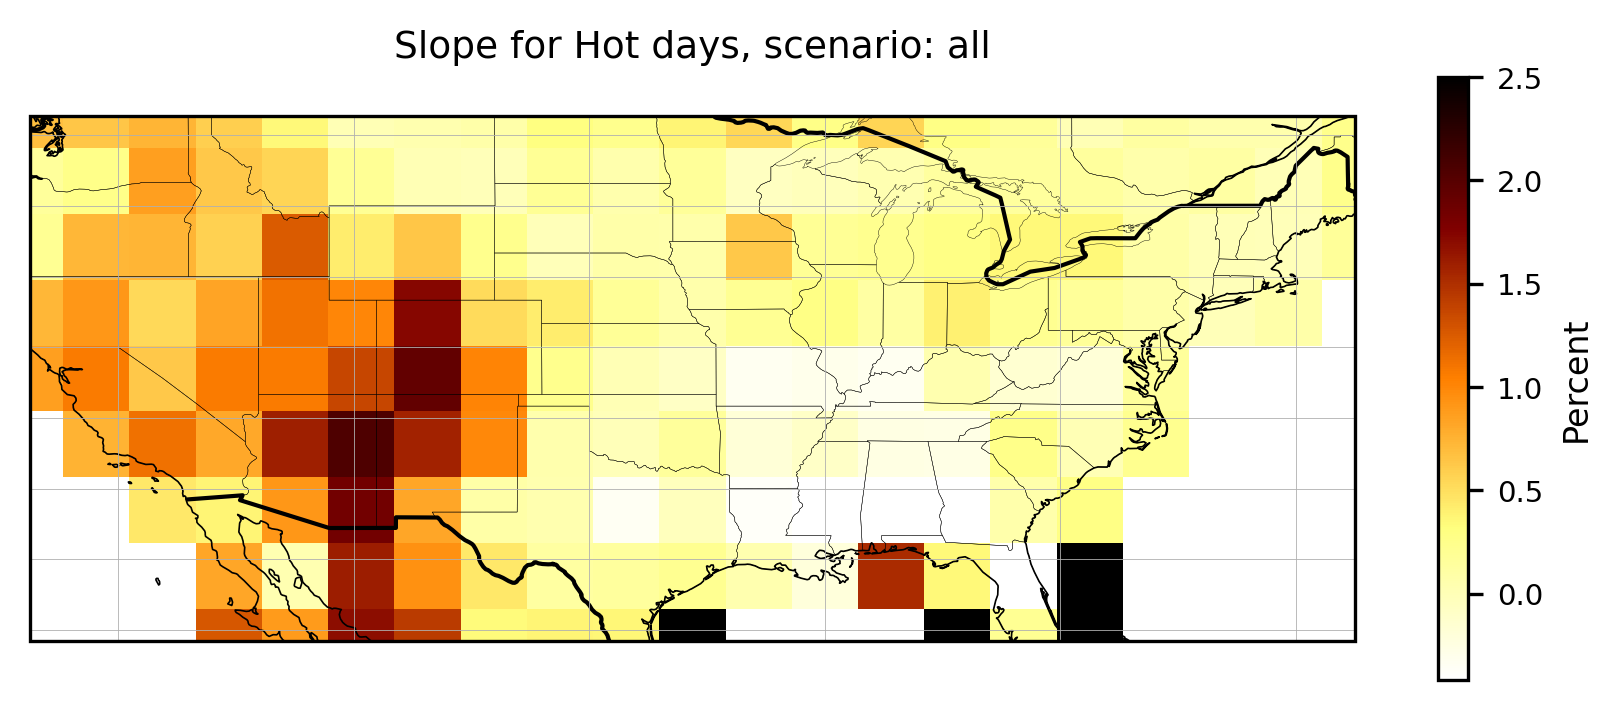

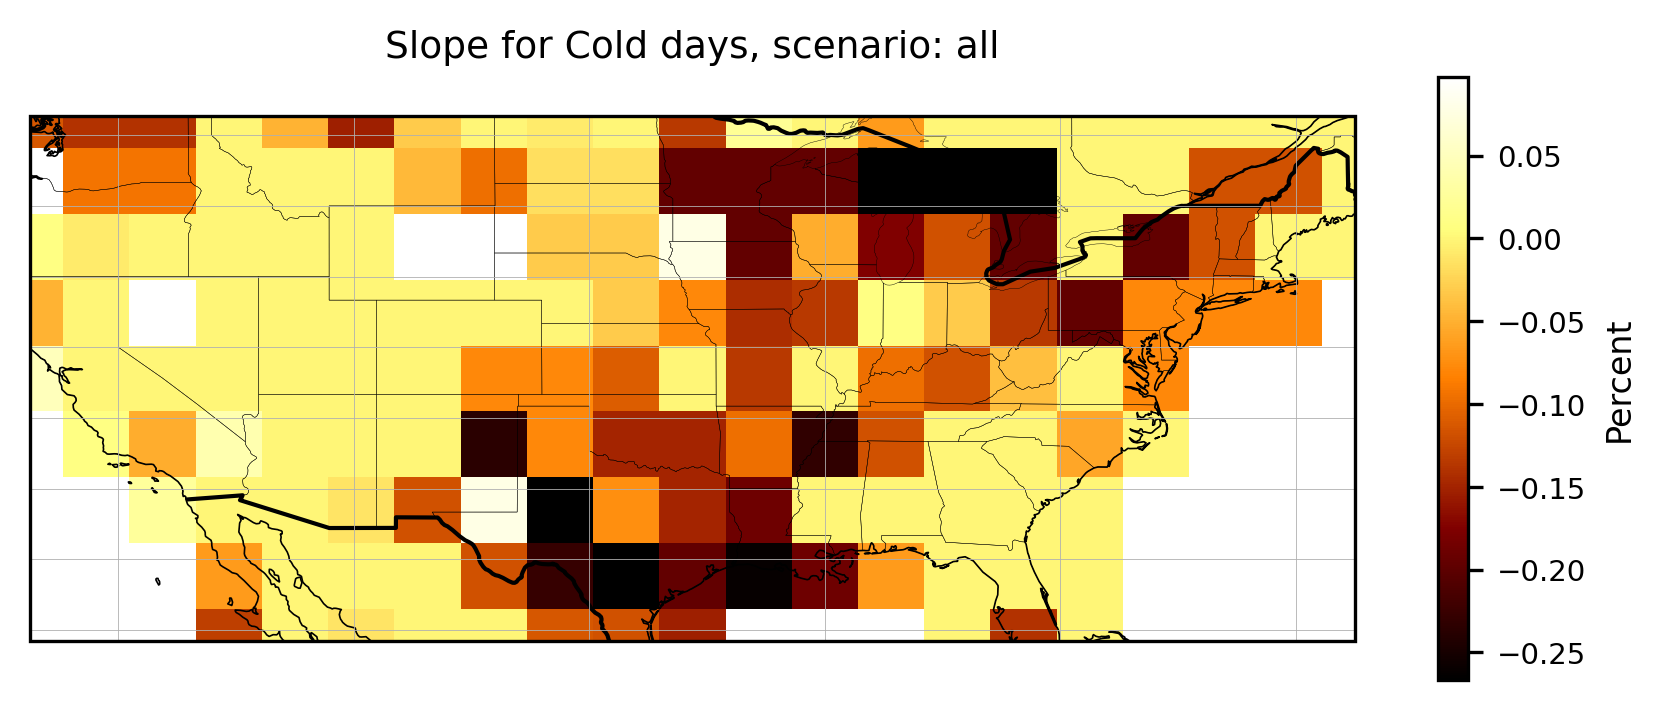

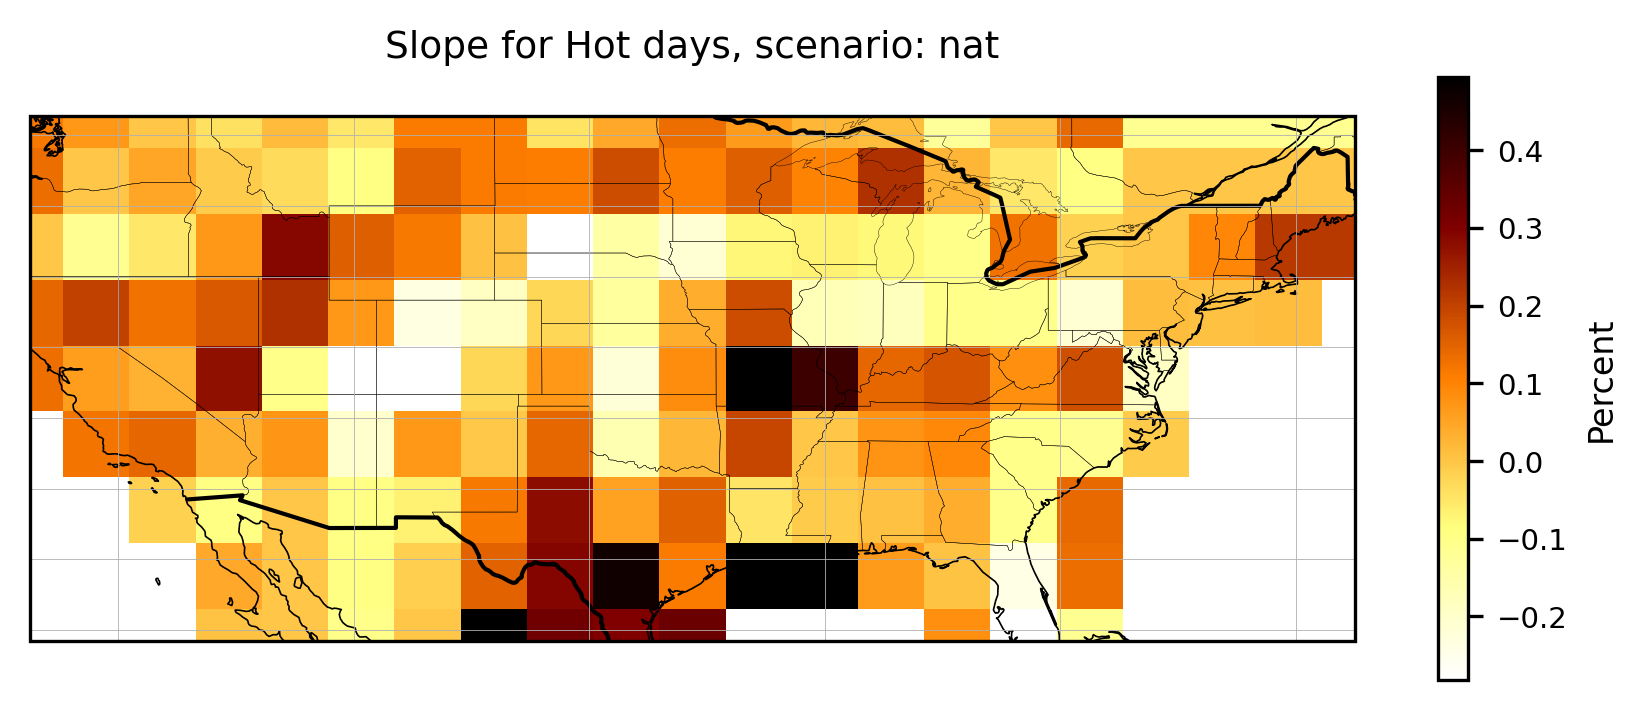

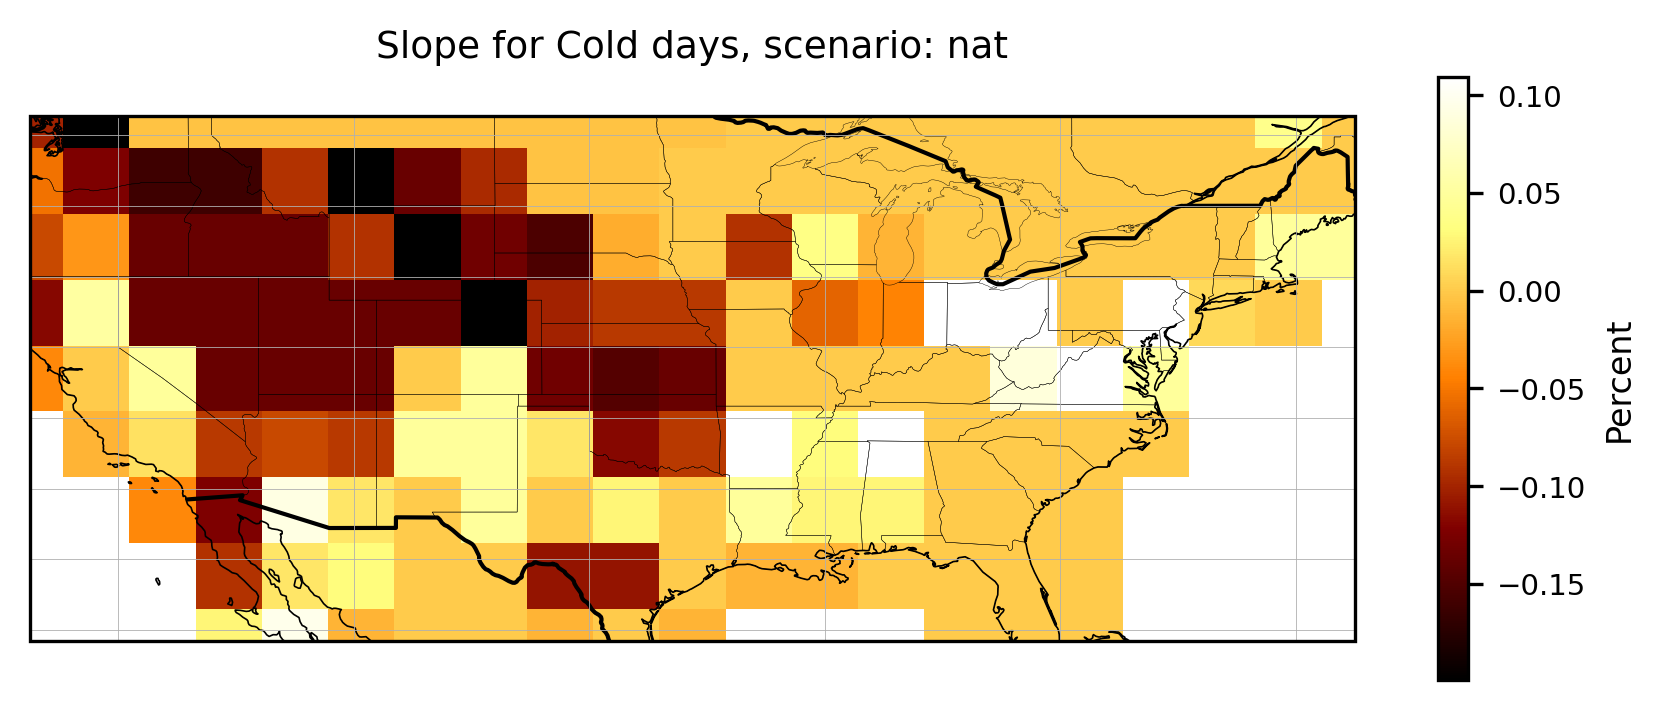

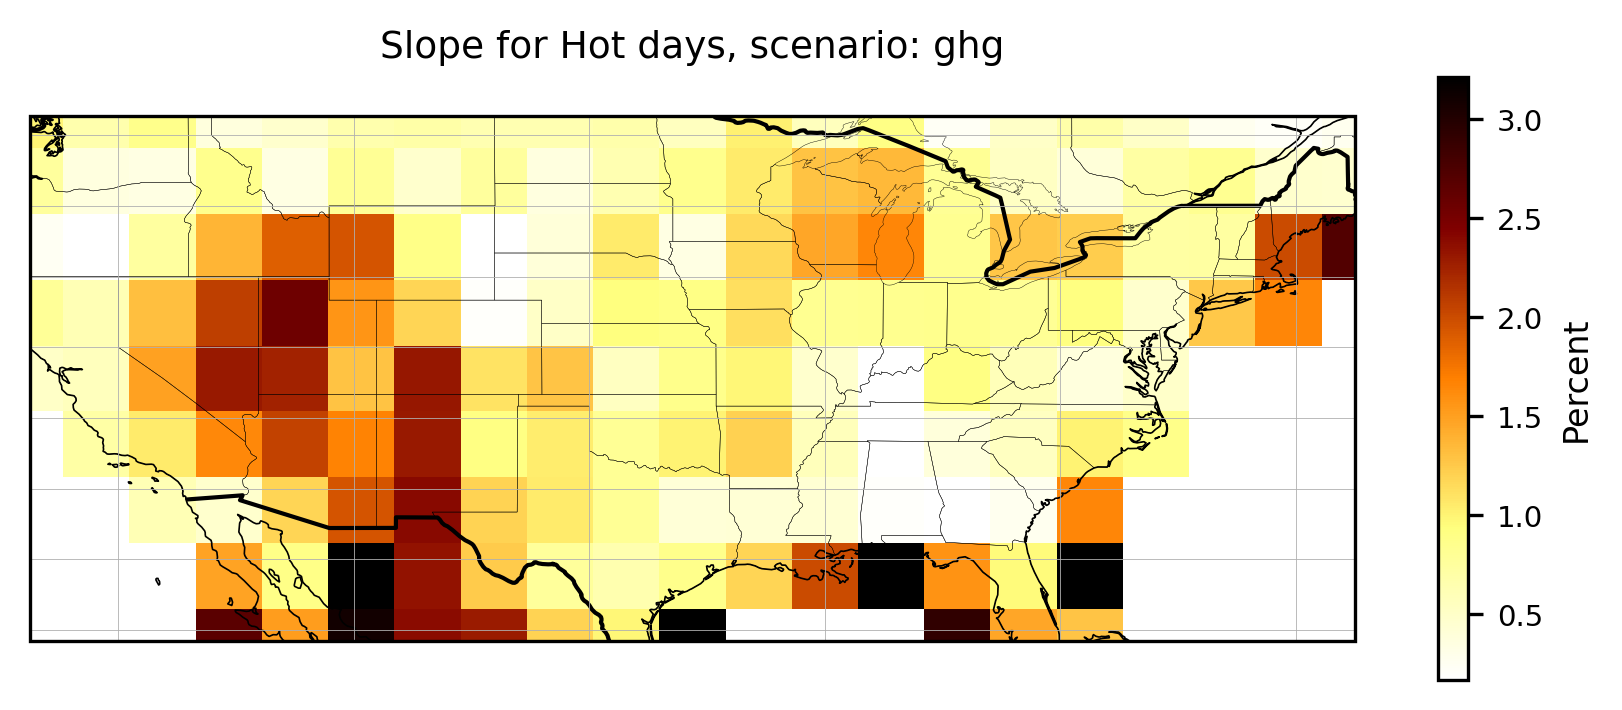

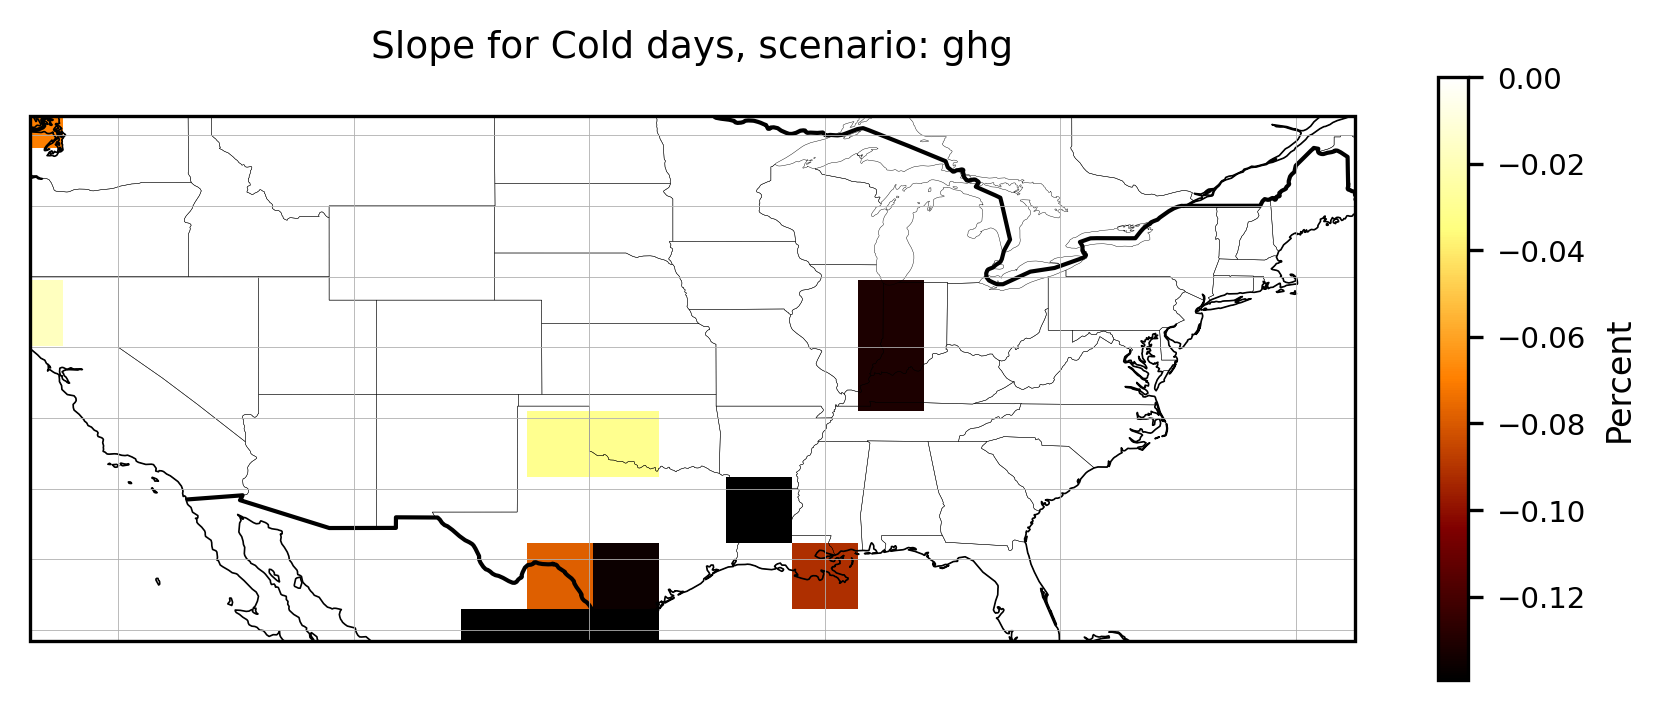

In [40]:
# Labels and colormaps
EXT_LABEL = {"heat": "Hot days", "cold": "Cold days"}
SLOPE_CMAP = {
    "heat": mpl.colormaps["afmhot_r"],
    "cold": mpl.colormaps["afmhot"],
}

# Font sizes consistent with previous maps
TITLE_FONTSIZE = 9
CBAR_LABELSIZE = 8
CBAR_TICKSIZE = 7
AX_TICKSIZE = 7

LON, LAT = np.meshgrid(lons_conus, lats_conus)

# Plotting slope per pixel
for sce in scenarios:
    for ext in temp_ext:
        data = np.asanyarray(th[ext]["slope_pp"][sce])
        if np.ma.isMaskedArray(data):
            data = data.filled(np.nan)
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)
        label = EXT_LABEL[ext]

        fig, ax = plt.subplots(
            figsize=fig_size,
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        mesh = ax.pcolormesh(
            LON,
            LAT,
            th[ext]["slope_pp"][sce],
            transform=ccrs.PlateCarree(),
            cmap=SLOPE_CMAP[ext],
            shading="nearest",
            vmin=vmin,
            vmax=vmax,
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        ax.gridlines(draw_labels=False, linewidth=0.2)
        ax.tick_params(labelsize=AX_TICKSIZE)

        cbar = plt.colorbar(
            mesh,
            ax=ax,
            shrink=0.5,
            #fraction=0.045,
            #pad=0.02,
        )
        cbar.ax.set_ylabel("Percent", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        ax.set_title(
            f"Slope for {label}, scenario: {sce}\n",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"slope_{ext}_{sce}.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

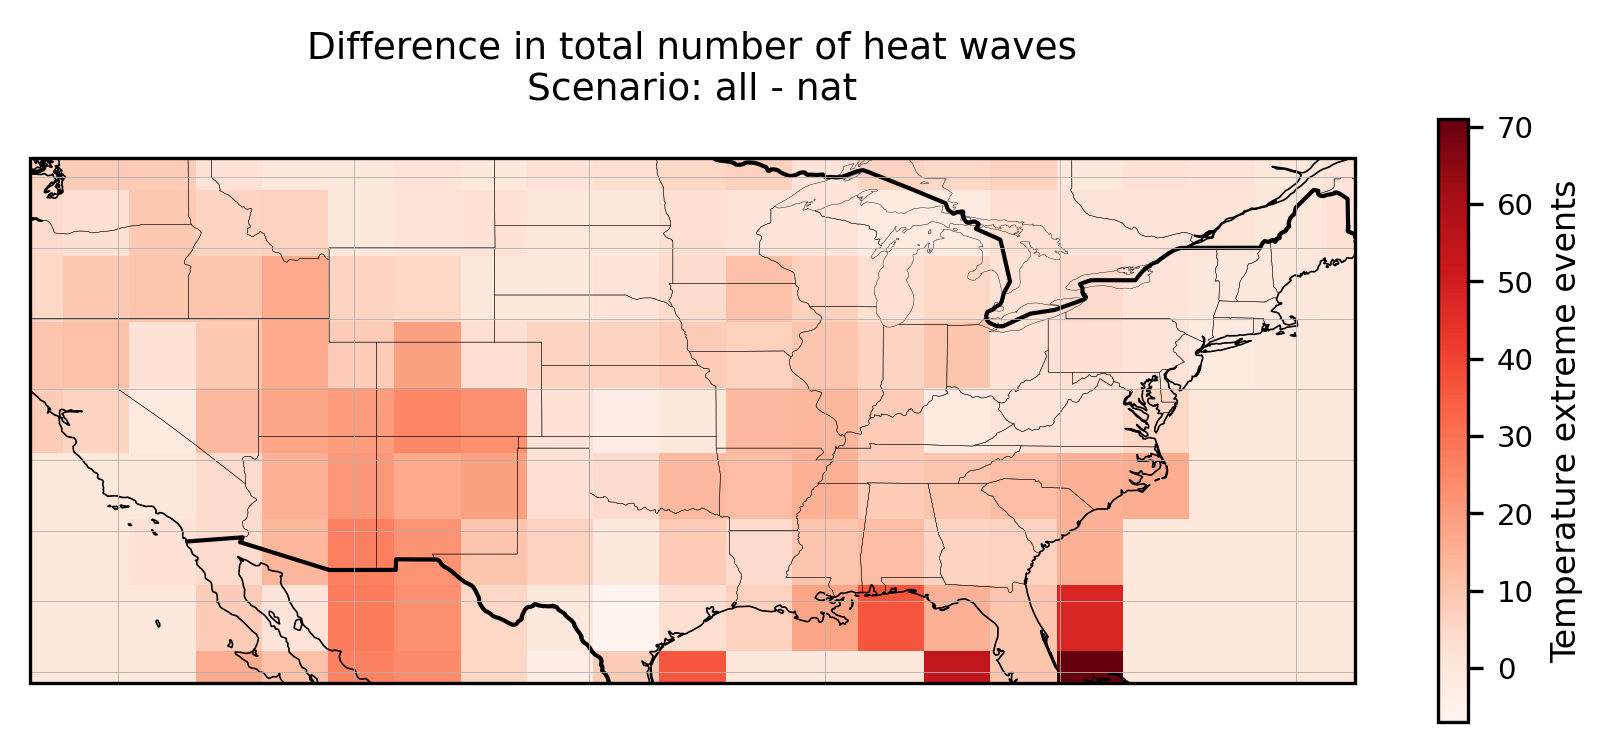

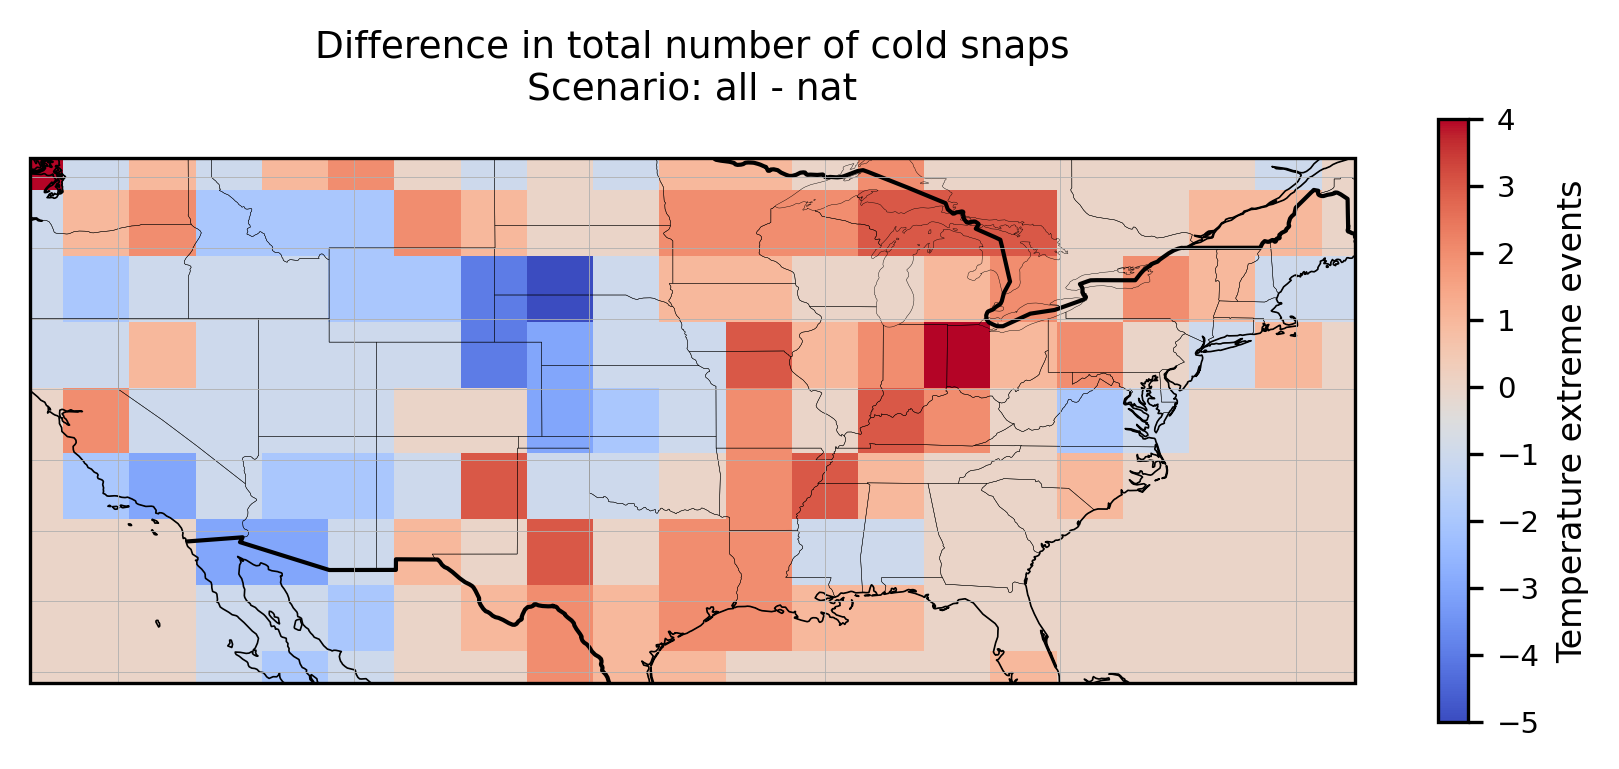

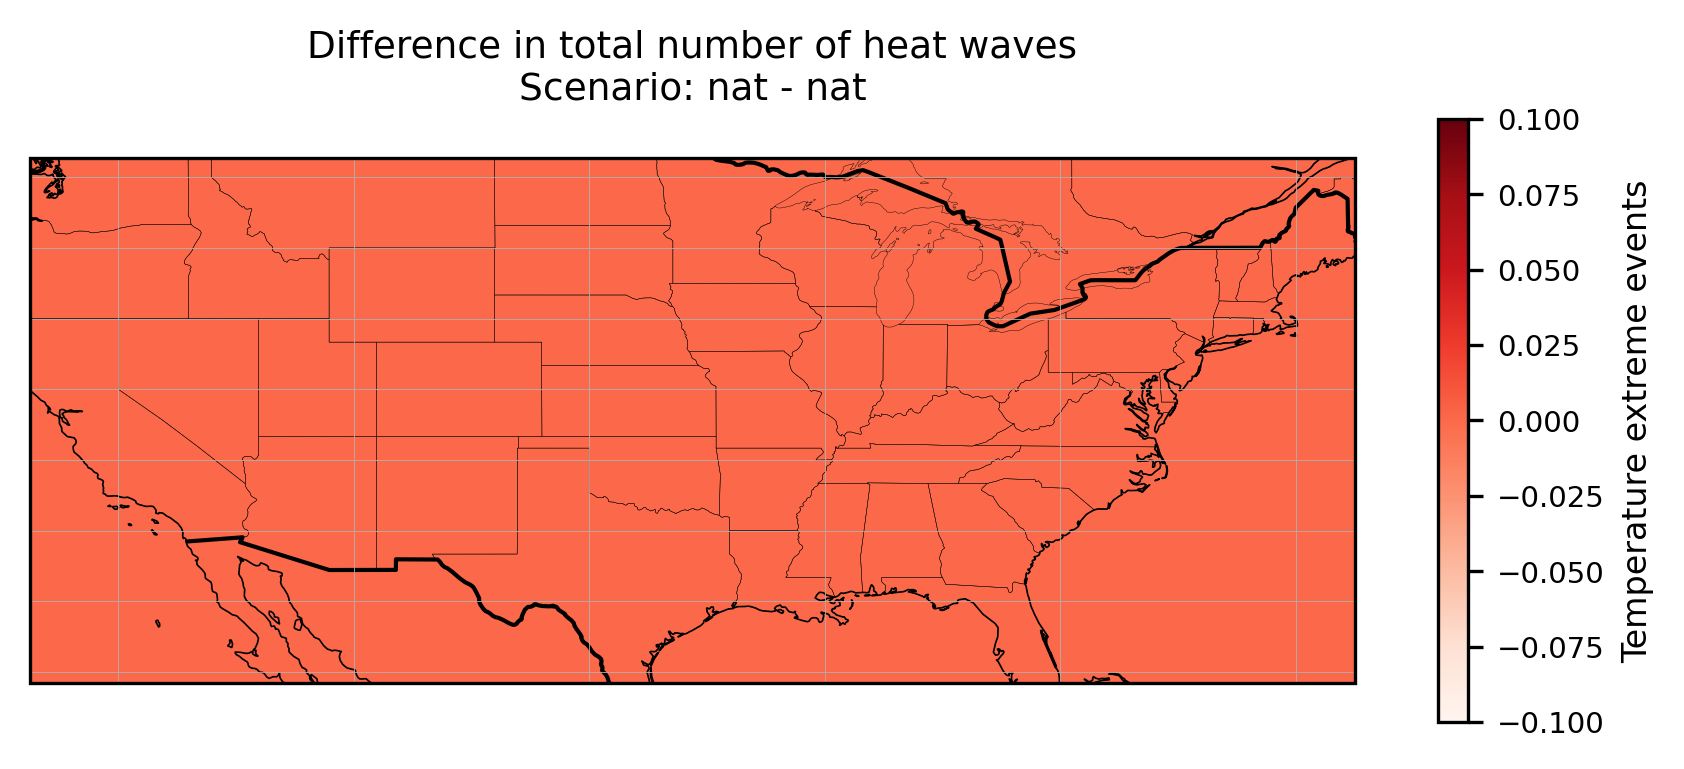

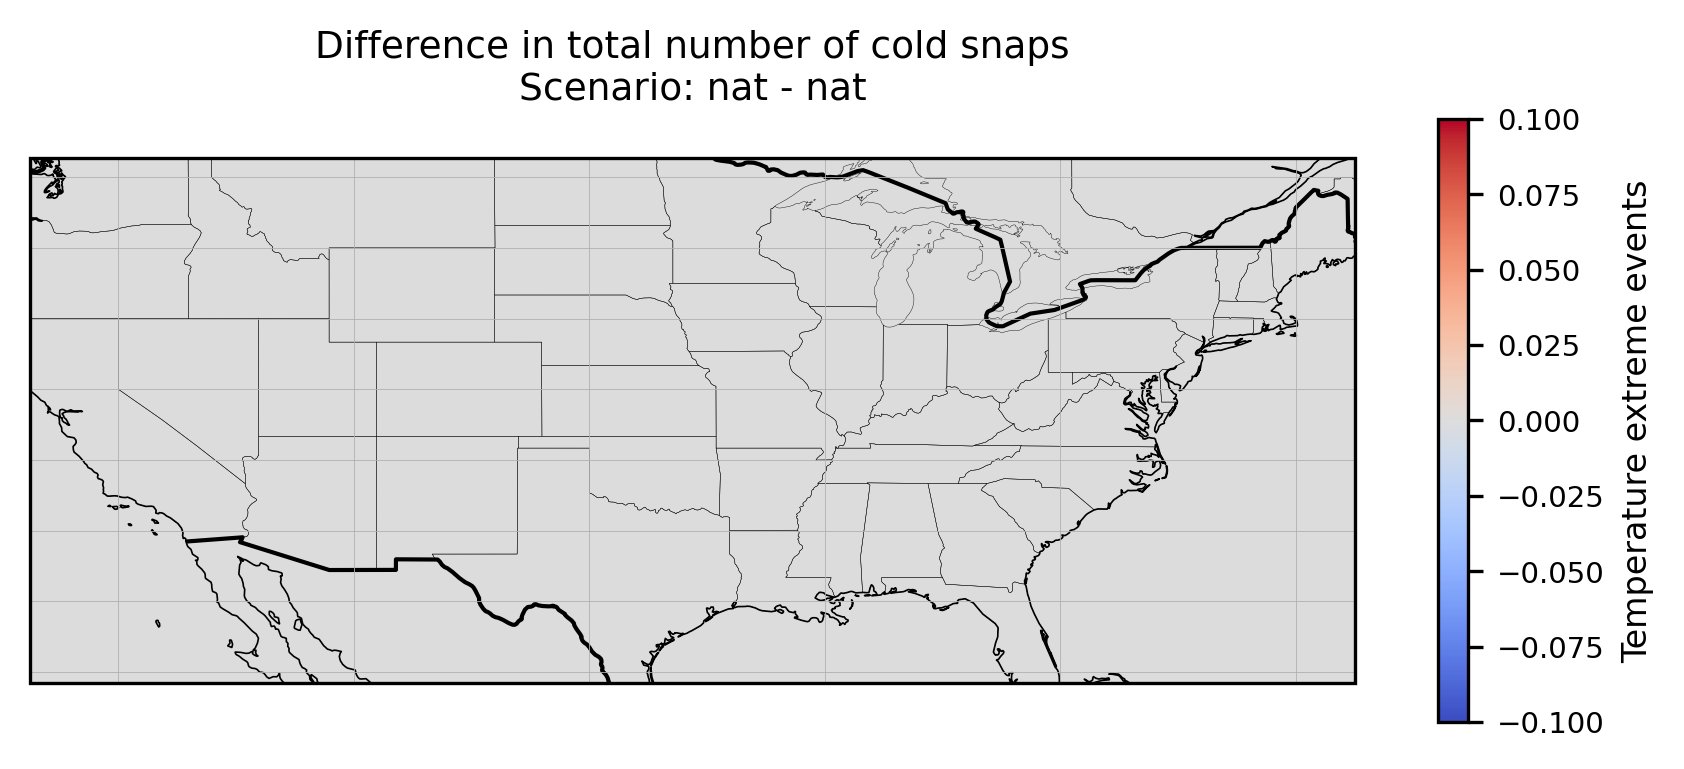

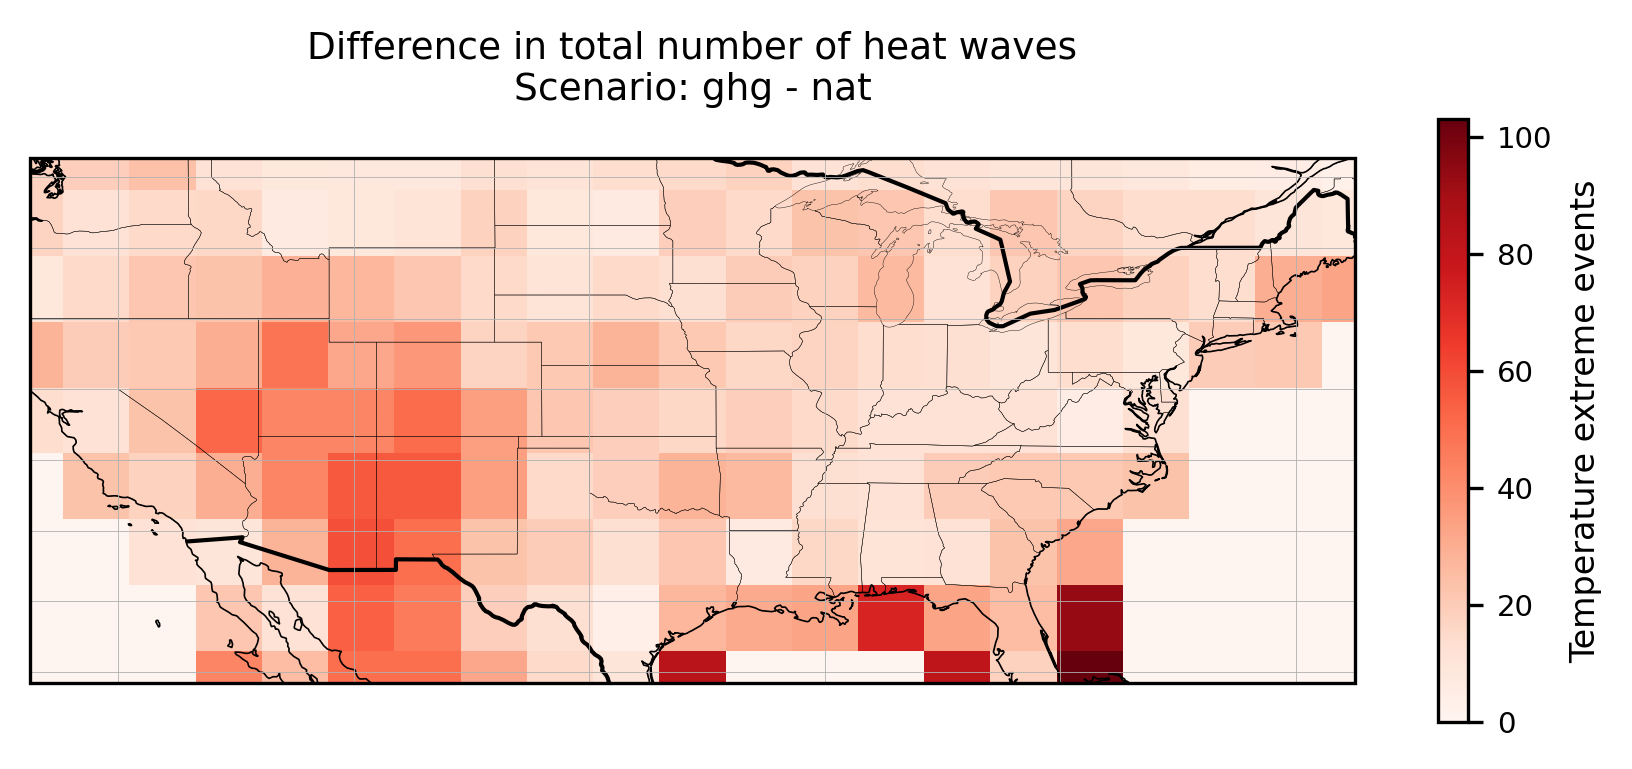

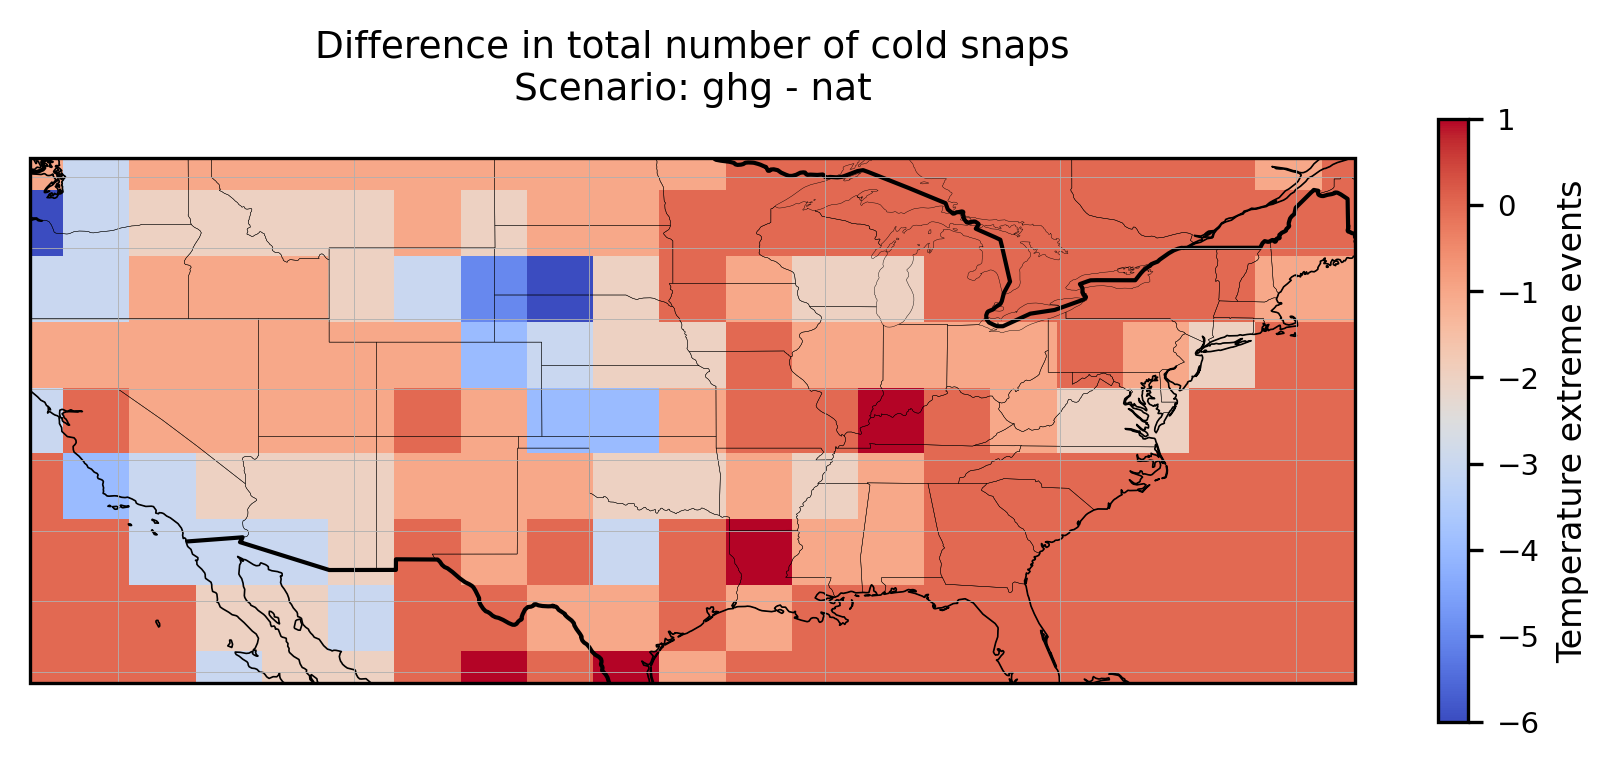

In [41]:


EXT_LABEL = {"heat": "heat waves", "cold": "cold snaps"}
EXT_CMAP_TOTAL_DIFF = {
    "heat": mpl.colormaps["Reds"],
    "cold": mpl.colormaps["coolwarm"],
}

TITLE_FONTSIZE = 9
CBAR_LABELSIZE = 8
CBAR_TICKSIZE = 7
AX_TICKSIZE = 7

LON, LAT = np.meshgrid(lons_conus, lats_conus)

# Spatial map of total increase in heat/cold waves (scenario vs nat)
for sce in scenarios:
    for ext in temp_ext:
        label = EXT_LABEL[ext]

        total_sce = np.sum(th[ext]["waves"][sce], axis=0)     # (lat, lon)
        total_nat = np.sum(th[ext]["waves"]["nat"], axis=0)   # (lat, lon)
        diff_events = total_sce - total_nat

        fig, ax = plt.subplots(
            figsize=fig_size,
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        mesh = ax.pcolormesh(
            LON,
            LAT,
            diff_events,
            transform=ccrs.PlateCarree(),
            cmap=EXT_CMAP_TOTAL_DIFF[ext],
            shading="nearest",
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        ax.gridlines(draw_labels=False, linewidth=0.2)
        ax.tick_params(labelsize=AX_TICKSIZE)

        cbar = plt.colorbar(
            mesh,
            ax=ax,
            shrink=0.5,
            #fraction=0.045,
            #pad=0.02,
        )
        cbar.ax.set_ylabel("Temperature extreme events", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        ax.set_title(
            f"Difference in total number of {label}\nScenario: {sce} - nat\n",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"diff_{ext}_waves_{sce}-nat.png")
        fig.savefig(fname, bbox_inches="tight")
        #plt.close(fig)

In [42]:
th["heat"]["waves_pr"] = {}
th["cold"]["waves_pr"] = {}

for sce in scenarios:
    for ext in temp_ext:
        hw_pr = np.zeros((len(yrs)))
        for idx, yr in enumerate(yrs):
            hw_pr[idx] = np.sum(th[ext]["waves"][sce][idx, :, :])
        th[ext]["waves_pr"][sce] = hw_pr.copy()
        print("The total HW/CS %s,%d yrs %s:%d" % (ext, len(yrs), sce, int(th[ext]["waves"][sce].sum())))

th["heat"]["waves_pr_stats"] = {}
th["cold"]["waves_pr_stats"] = {}
for sce in scenarios:
    th["heat"]["waves_pr_stats"][sce] = {}
    th["cold"]["waves_pr_stats"][sce] = {}
# finding the stats of the increase/decrease of heat waves/cold snaps
for sce in scenarios:
    (
        th["heat"]["waves_pr_stats"][sce]["slope"],
        th["heat"]["waves_pr_stats"][sce]["intercept"],
        th["heat"]["waves_pr_stats"][sce]["rvalue"],
        th["heat"]["waves_pr_stats"][sce]["pvalue"],
        th["heat"]["waves_pr_stats"][sce]["stderr"],
    ) = stats.linregress(yrs, th["heat"]["waves_pr"][sce])
    (
        th["cold"]["waves_pr_stats"][sce]["slope"],
        th["cold"]["waves_pr_stats"][sce]["intercept"],
        th["cold"]["waves_pr_stats"][sce]["rvalue"],
        th["cold"]["waves_pr_stats"][sce]["pvalue"],
        th["cold"]["waves_pr_stats"][sce]["stderr"],
    ) = stats.linregress(yrs, th["cold"]["waves_pr"][sce])

for sce in scenarios:
    for ext in temp_ext:
        trend_tmp = []
        for y in yrs:
            trend_tmp.append(th[ext]["waves_pr_stats"][sce]["slope"] * y + th[ext]["waves_pr_stats"][sce]["intercept"])
        th[ext]["waves_pr_stats"][sce]["trend"] = np.array(trend_tmp)


The total HW/CS heat,65 yrs all:1908
The total HW/CS cold,65 yrs all:196
The total HW/CS heat,65 yrs nat:638
The total HW/CS cold,65 yrs nat:189
The total HW/CS heat,65 yrs ghg:4247
The total HW/CS cold,65 yrs ghg:17


In [43]:
for sce in scenarios:
    for ext in temp_ext:
        print(
            "pvalue_%s_%s :" % (sce, ext),
            th[ext]["waves_pr_stats"][sce]["pvalue"],
            "rvalue_%s_%s :" % (sce, ext),
            th[ext]["waves_pr_stats"][sce]["rvalue"],
        )

pvalue_all_heat : 1.505542273588514e-08 rvalue_all_heat : 0.6332708859745287
pvalue_all_cold : 0.05783664256889763 rvalue_all_cold : -0.23652463484272107
pvalue_nat_heat : 0.3112957861097761 rvalue_nat_heat : 0.127546996389025
pvalue_nat_cold : 0.4018167753841204 rvalue_nat_cold : -0.1057482007104594
pvalue_ghg_heat : 2.9441818734353482e-12 rvalue_ghg_heat : 0.7356752172678704
pvalue_ghg_cold : 0.01571927261079417 rvalue_ghg_cold : -0.29851633236509034


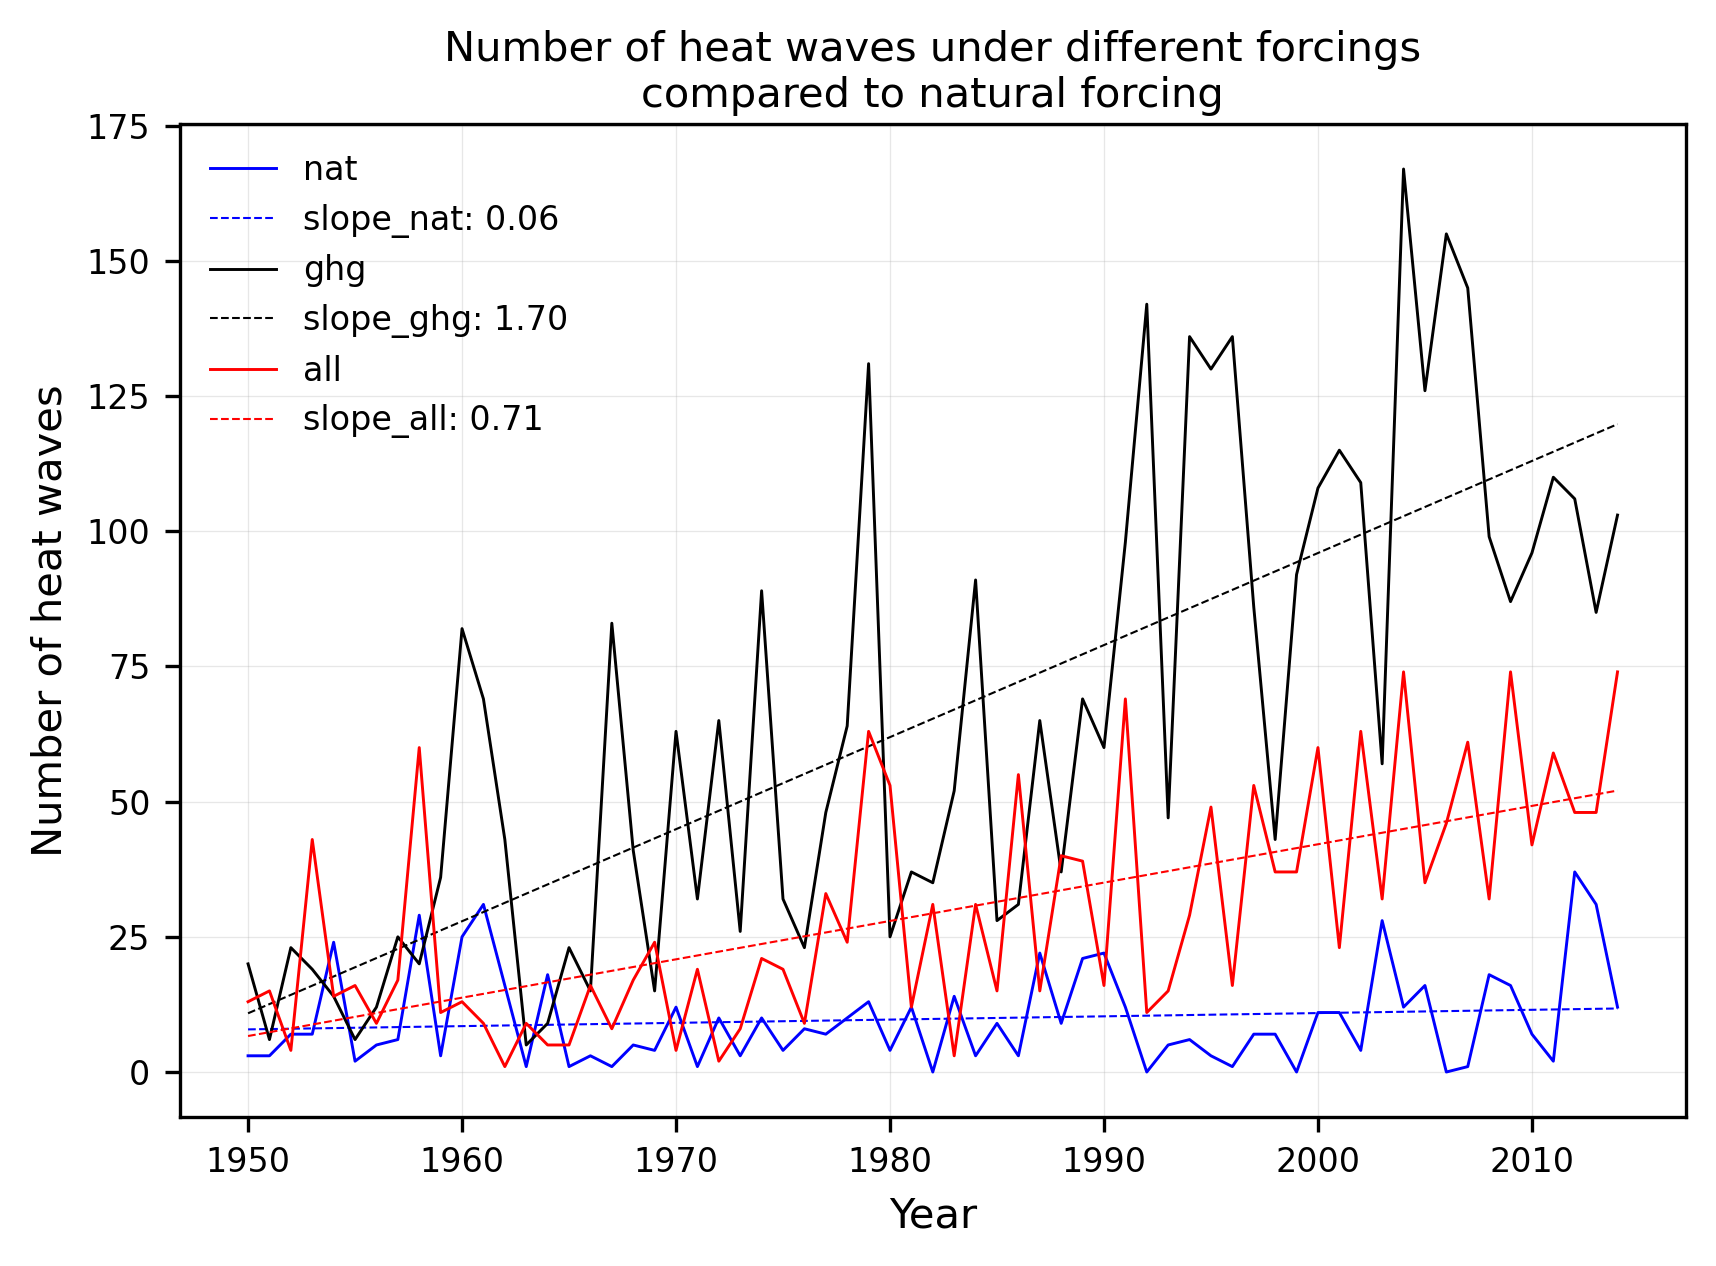

In [44]:
# 1. Compute trend statistics for heat waves
th["heat"]["waves_pr_stats"] = {}

for sce in scenarios:
    th["heat"]["waves_pr_stats"][sce] = {}
    # waves_pr[sce]: 1D array, length = len(yrs), number of heat waves per year
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(
        yrs, th["heat"]["waves_pr"][sce]
    )
    stats_dict = th["heat"]["waves_pr_stats"][sce]
    stats_dict["slope"] = slope
    stats_dict["intercept"] = intercept
    stats_dict["rvalue"] = rvalue
    stats_dict["pvalue"] = pvalue
    stats_dict["stderr"] = stderr
    stats_dict["trend"] = slope * np.asarray(yrs) + intercept

# 2. Plot style (consistent with previous time-series)
title_fs = 10
label_fs = 10
tick_fs = 8
legend_fs = 8
line_fs = 0.7
trend_fs = 0.5

colors = {"nat": "b", "ghg": "k", "all": "r"}

# 3. Heat waves plot
fig, ax = plt.subplots(figsize=fig_size, dpi=300, tight_layout=True)

for sce in ["nat", "ghg", "all"]:
    ax.plot(
        yrs,
        th["heat"]["waves_pr"][sce],
        color=colors[sce],
        linewidth=line_fs,
        label=sce,
    )
    ax.plot(
        yrs,
        th["heat"]["waves_pr_stats"][sce]["trend"],
        linestyle="--",
        color=colors[sce],
        linewidth=trend_fs,
        label=f"slope_{sce}: {th['heat']['waves_pr_stats'][sce]['slope']:.2f}",
    )

ax.set_title(
    "Number of heat waves under different forcings\ncompared to natural forcing",
    fontsize=title_fs,
    pad=4,
)
ax.set_xlabel("Year", fontsize=label_fs)
ax.set_ylabel("Number of heat waves", fontsize=label_fs)
ax.tick_params(axis="both", labelsize=tick_fs)
ax.legend(fontsize=legend_fs, frameon=False)
ax.grid(alpha=0.3, linewidth=0.3)

fig.savefig(os.path.join(out_path, "heat_waves_py.png"), bbox_inches="tight")
#plt.close(fig)

# attr

In [45]:
def norm(arr):
    if np.max(arr) == np.min(arr):
        return np.array([0] * len(arr))
    return np.array([(x - np.min(arr)) / (np.max(arr) - np.min(arr)) for x in arr])

In [46]:
temp_ext

array(['heat', 'cold'], dtype='<U4')

In [47]:

th["heat"]["attr_tmax"] = {}
th["cold"]["attr_tmin"] = {}

for sce in scenarios:
    for ext in temp_ext:
        if ext == "heat":
            print(sce, ext)
    
            ds = conus_t[ext][sce]         # Dataset with 'tasmax' and 'time'
            tasmax_da = ds["tasmax"]
    
            # Group by calendar year and take max over time, lat, lon
            # Assumes time is something like cftime.DatetimeNoLeap or datetime64
            tmax_year_da = tasmax_da.groupby("time.year").max(dim=("time", "lat", "lon"))
    
            # Make sure we align with your yrs array
            tmax_yearly = tmax_year_da.sel(year=yrs).values
    
            th[ext]["attr_tmax"][sce] = np.asarray(tmax_yearly)
        if ext == "cold":
            print(sce, ext)
    
            ds = conus_t[ext][sce]         # Dataset with 'tasmax' and 'time'
            tasmin_da = ds["tasmin"]
    
            # Group by calendar year and take max over time, lat, lon
            # Assumes time is something like cftime.DatetimeNoLeap or datetime64
            tmin_year_da = tasmin_da.groupby("time.year").max(dim=("time", "lat", "lon"))
    
            # Make sure we align with your yrs array
            tmin_yearly = tmin_year_da.sel(year=yrs).values
    
            th[ext]["attr_tmin"][sce] = np.asarray(tmin_yearly)

all heat
all cold
nat heat
nat cold
ghg heat
ghg cold


In [48]:
# Linear regressions: Tmax vs annual heat-wave counts
m_tmax_all, c_tmax_all, r_all, p_tmax_all, stderr_all = stats.linregress(
    th["heat"]["attr_tmax"]["all"],
    th["heat"]["waves_pr"]["all"],
)

m_tmax_nat, c_tmax_nat, r_nat, p_tmax_nat, stderr_nat = stats.linregress(
    th["heat"]["attr_tmax"]["nat"],
    th["heat"]["waves_pr"]["nat"],
)

beta = float(c_tmax_all / c_tmax_nat)
print("beta:", beta)
print(
    "slope_all:", m_tmax_all, "p_all:", p_tmax_all,
    "\n",
    "slope_nat:", m_tmax_nat, "p_nat:", p_tmax_nat,
)

beta: 2.7416021833138142
slope_all: 11.79221821690013 p_all: 4.5867176172037374e-08 
 slope_nat: 4.343065232636115 p_nat: 0.0001183882351339971


In [49]:
dict_att = {
    "all": np.asarray(th["heat"]["waves_pr"]["all"]),
    "nat": np.asarray(th["heat"]["waves_pr"]["nat"]),
}

df_att = pd.DataFrame.from_dict(dict_att)
df_att.index = yrs

lm = smf.ols(formula="all ~ nat", data=df_att).fit()

print("OLS parameters (all ~ nat):")
print(lm.params)
print("p-values:")
print(lm.pvalues)

median_ratio = np.median(
    th["heat"]["waves_pr"]["all"] / th["heat"]["waves_pr"]["nat"]
)
print("Median ratio of HW 'all' / 'nat':", median_ratio)

OLS parameters (all ~ nat):
Intercept    27.228917
nat           0.216490
dtype: float64
p-values:
Intercept    2.661384e-09
nat          4.686499e-01
dtype: float64
Median ratio of HW 'all' / 'nat': 4.625


/tmp/ipykernel_301900/3074974195.py:17: RuntimeWarning: divide by zero encountered in divide
  th["heat"]["waves_pr"]["all"] / th["heat"]["waves_pr"]["nat"]


## population

In [50]:
us_cities = pd.read_csv('cities.csv')
us_cities

,Rank_2025,City,State,Population_Estimate_2000,Population_Estimate_2025,Population_Growth_2000_to_2025_Pct,Latitude,Longitude,Population_2000_Source_URL,Population_2025_Source_URL,Coordinates_Source_URL
0,1,New York,New York,8017608,8584629,7.07,40.712784,-74.005941,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
1,2,Los Angeles,California,3701062,3869089,4.54,34.052234,-118.243685,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
2,3,Chicago,Illinois,2891582,2731585,-5.53,41.878114,-87.629798,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
3,4,Houston,Texas,1974324,2397315,21.42,29.760427,-95.369803,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
4,5,Phoenix,Arizona,1326682,1665481,25.54,33.448377,-112.074037,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
5,6,Philadelphia,Pennsylvania,1514563,1574281,3.94,39.952584,-75.165222,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
6,7,San Antonio,Texas,1153843,1548422,34.20,29.424122,-98.493628,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
7,8,San Diego,California,1227854,1406106,14.52,32.715738,-117.161084,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
8,9,Dallas,Texas,1188168,1329491,11.89,32.776664,-96.796988,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...
9,10,Fort Worth,Texas,547484,1028117,87.79,32.755488,-97.330766,https://www2.census.gov/programs-surveys/popes...,https://www2.census.gov/programs-surveys/popes...,https://gist.github.com/Miserlou/c5cd8364bf9b2...


In [51]:
slope_hw = []
slope_cs = []

In [52]:
for rank in range(30):
    city_lat = us_cities.loc[rank]['Latitude']
    city_lon = us_cities.loc[rank]['Longitude']
    m_hw = th['heat']['slope_pp']['all'][geo_idx(city_lat,lats_conus),geo_idx(city_lon+360,lons_conus)]
    m_cs = th['cold']['slope_pp']['all'][geo_idx(city_lat,lats_conus),geo_idx(city_lon+360,lons_conus)]
    slope_hw.append(m_hw)
    slope_cs.append(m_cs)
us_cities['Slope_HW'] = slope_hw
us_cities['Slope_CS'] = slope_cs

In [53]:
us_cities.to_csv('cities_HW.csv')

# Future-hist

In [54]:
start_year

1950

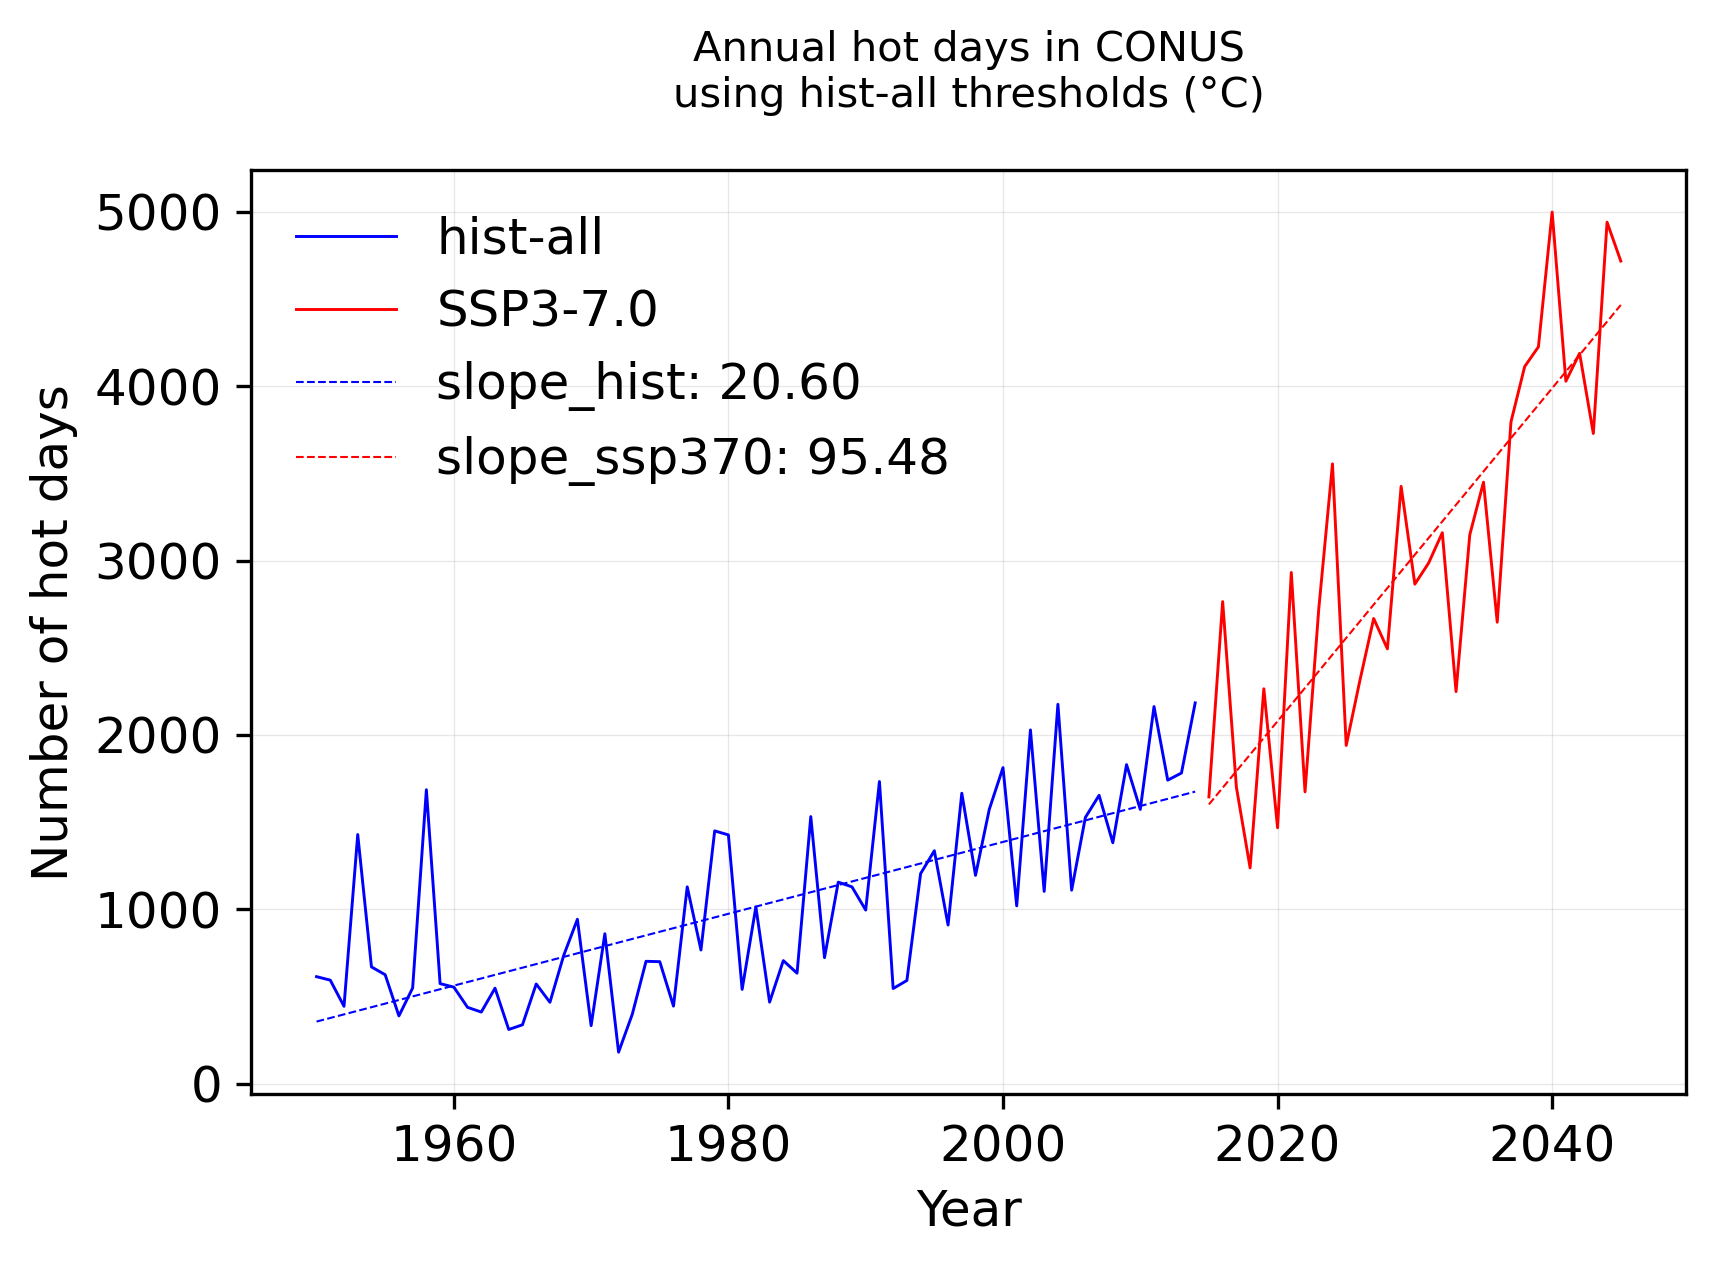

In [55]:

# 1. Subset SSP370 data to 2015–2045 CONUS
ds_tmax_ssp = nc_tmax_full.sel(
    time=slice("2015-01-01", "2045-12-31"),
    lat=slice(bottom, top),
    lon=slice(left, right),
)

# hist-all heat threshold grid (lat, lon)
heat_thr_hist_all = th["heat"]["grid"]["all"]  # masked array or DataArray (lat, lon)

# 2. Compute annual hot-day totals in SSP370 using hist-all thresholds
yrs_future = np.arange(2015, 2046)
hot_days_future_total = np.zeros(len(yrs_future))

for i, yr in enumerate(yrs_future):
    ds_year = ds_tmax_ssp.sel(time=str(yr))
    # K → °C
    tmax_year = ds_year.tasmax - 273.15

    # broadcast threshold to time dimension
    thr = np.broadcast_to(heat_thr_hist_all, tmax_year.shape)

    hot_mask = tmax_year.values > thr  # True where T > hist-all threshold
    # sum over time, lat, lon
    hot_days_future_total[i] = hot_mask.sum()

# 3. Historical all-forcings totals from your existing analysis
yrs_hist = yrs  # e.g. np.arange(1982, 2019+1)
hot_days_hist_total = th["heat"]["day_comp"]["all"][:, 1]  # CONUS totals

# 4. Plot time series with trends
fig, ax = plt.subplots(figsize=fig_size, dpi=300, tight_layout=True)

# Historical all
ax.plot(yrs_hist, hot_days_hist_total, "b", linewidth=0.7, label="hist-all")

# SSP370 future
ax.plot(yrs_future, hot_days_future_total, "r", linewidth=0.7, label="SSP3-7.0")

# Linear trends
slope_hist, intercept_hist, *_ = stats.linregress(yrs_hist, hot_days_hist_total)
slope_fut, intercept_fut, *_ = stats.linregress(yrs_future, hot_days_future_total)

ax.plot(
    yrs_hist,
    slope_hist * yrs_hist + intercept_hist,
    "b--",
    linewidth=0.5,
    label=f"slope_hist: {slope_hist:.2f}",
)

ax.plot(
    yrs_future,
    slope_fut * yrs_future + intercept_fut,
    "r--",
    linewidth=0.5,
    label=f"slope_ssp370: {slope_fut:.2f}",
)

ax.set_title(
    "Annual hot days in CONUS\nusing hist-all thresholds (°C)\n",
    fontsize=10,
    pad=4,
)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of hot days", fontsize=12)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, frameon=False)
ax.grid(alpha=0.3, linewidth=0.3)

fig.savefig(os.path.join(out_path, "hot_days_future_ssp370_vs_hist.png"), bbox_inches="tight")
#plt.close(fig)

In [56]:
# Future years
yrs_future = np.arange(2015, 2046)

# Store future heat-wave counts
waves_pr_future = {"ssp370": np.zeros(len(yrs_future))}
waves_future_grid = {
    "ssp370": np.ma.masked_array(
        np.zeros(
            (len(yrs_future), ocean_mask_conus.mask.shape[0], ocean_mask_conus.mask.shape[1])
        ),
        mask=np.broadcast_to(
            ocean_mask_conus.mask,
            (len(yrs_future), ocean_mask_conus.mask.shape[0], ocean_mask_conus.mask.shape[1]),
        ).copy(),
    )
}

# Historical all-forcing threshold grid (lat, lon)
heat_thr_hist_all = np.asanyarray(th["heat"]["grid"]["all"])

# Structure for 1D connected features
str_hw = np.ones((3,), dtype=int)

# Subset SSP370 Tmax over the future period and CONUS
ds_tmax_ssp = nc_tmax_full.sel(
    time=slice("2015-01-01", "2045-12-31"),
    lat=slice(bottom, top),
    lon=slice(left, right),
)

for i, yr in enumerate(yrs_future):
    ds_year = ds_tmax_ssp.sel(time=str(yr))
    tmax_year_da = ds_year["tasmax"] - 273.15   # adjust variable name if needed
    tmax_year = tmax_year_da.values             # shape (time, lat, lon)

    # Daily hot-day mask using fixed hist-all threshold
    thr = np.broadcast_to(heat_thr_hist_all, tmax_year.shape)
    hot_mask = tmax_year > thr   # boolean array, shape (time, lat, lon)

    for idx_lat in range(ocean_mask_conus.mask.shape[0]):
        for idx_lon in range(ocean_mask_conus.mask.shape[1]):

            # Skip ocean / masked cells
            if ocean_mask_conus.mask[idx_lat, idx_lon]:
                continue

            tmp_ar = hot_mask[:, idx_lat, idx_lon]

            # Label continuous hot-day events
            larray, narray = ndimage.label(tmp_ar, structure=str_hw)

            if narray > 0:
                locations = ndimage.find_objects(larray)
                hw_count = []
                for loc in locations:
                    consec_days = np.sum(tmp_ar[loc])
                    if consec_days > 5:
                        hw_count.append(1)
                hw_count = np.array(hw_count)
            else:
                hw_count = np.array([0])

            waves_future_grid["ssp370"][i, idx_lat, idx_lon] = np.sum(hw_count)

    # CONUS total number of heat waves for this year
    waves_pr_future["ssp370"][i] = np.ma.sum(waves_future_grid["ssp370"][i, :, :])

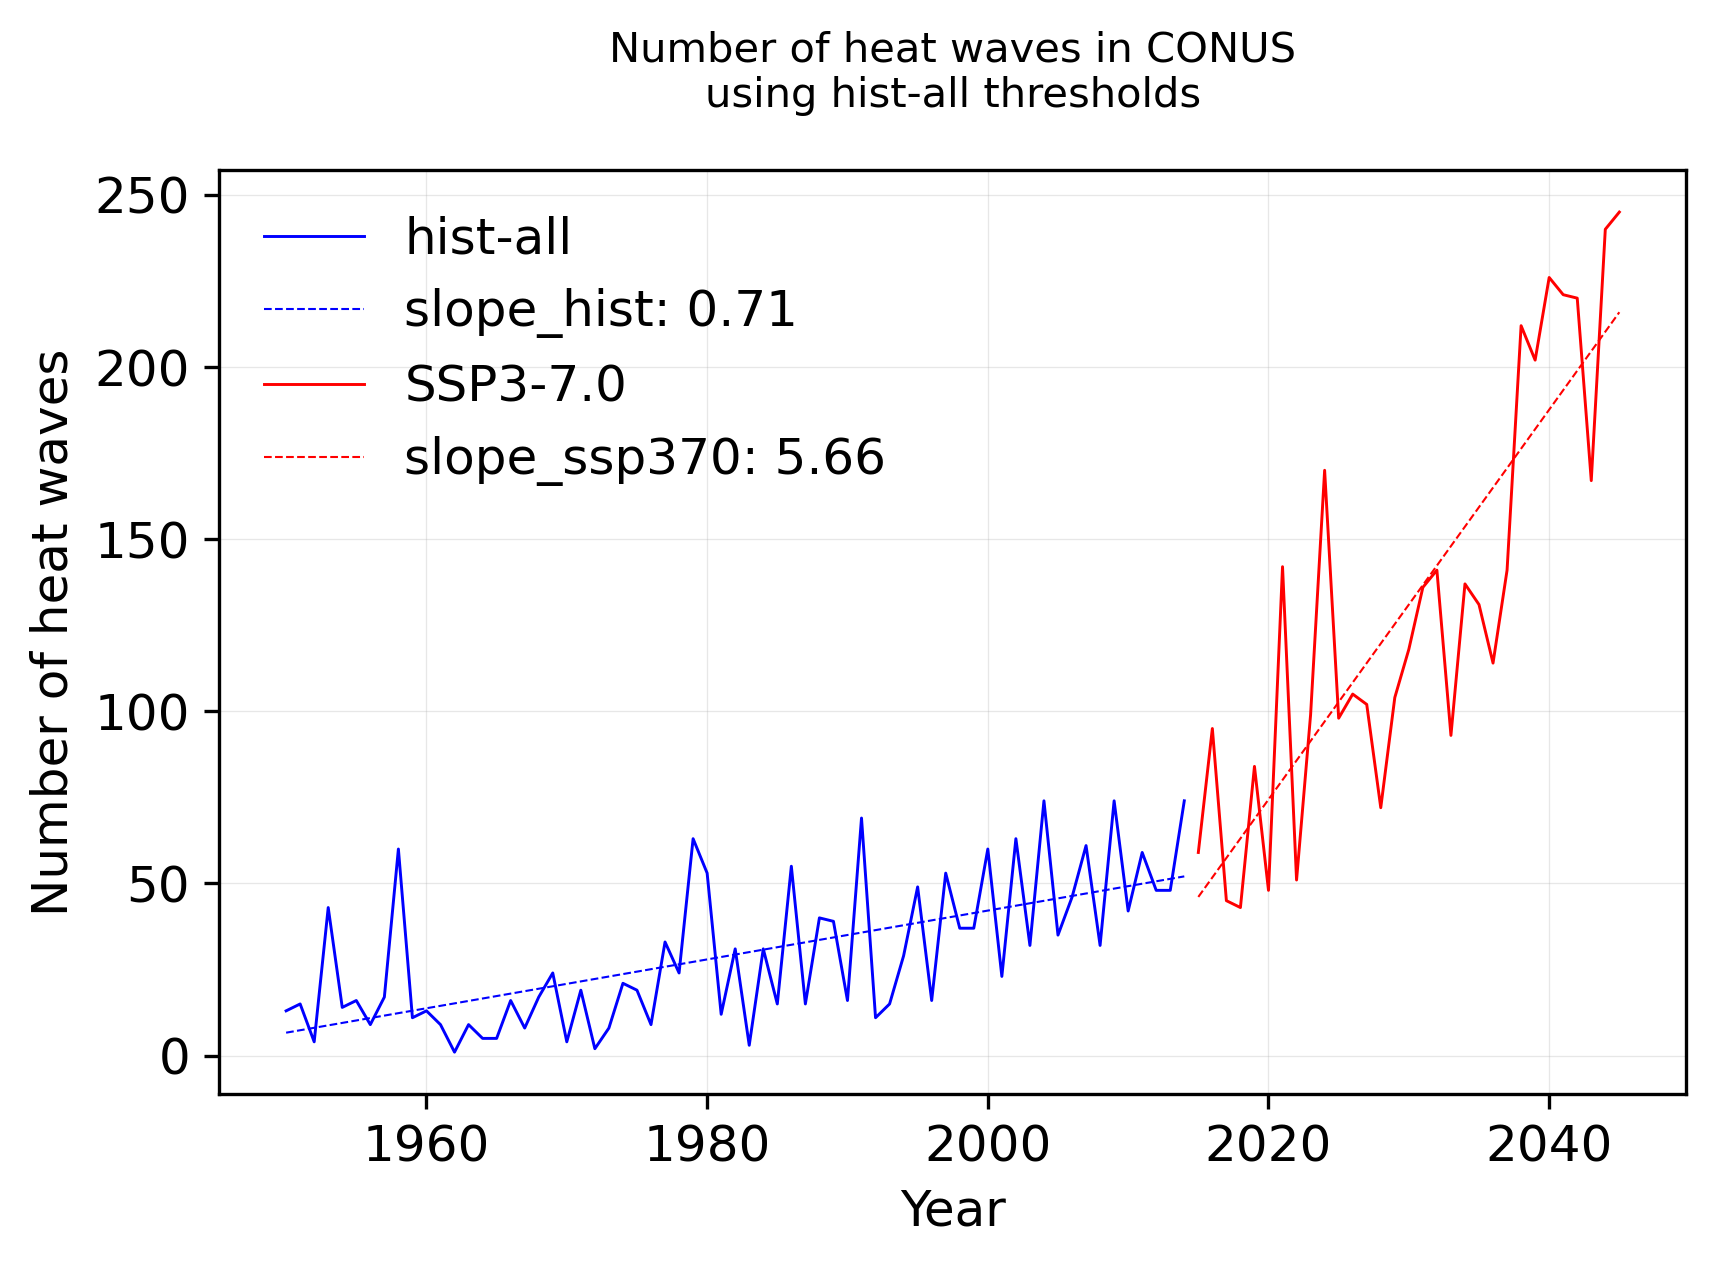

In [62]:
yrs_hist = yrs
waves_hist_all = np.asarray(th["heat"]["waves_pr"]["all"])
waves_ssp370 = np.asarray(waves_pr_future["ssp370"])

fig, ax = plt.subplots(figsize=fig_size, dpi=300, tight_layout=True)

ax.plot(yrs_hist, waves_hist_all, "b", linewidth=0.7, label="hist-all")
slope_hist, intercept_hist, *_ = stats.linregress(yrs_hist, waves_hist_all)
ax.plot(
    yrs_hist,
    slope_hist * yrs_hist + intercept_hist,
    "b--",
    linewidth=0.5,
    label=f"slope_hist: {slope_hist:.2f}",
)

ax.plot(yrs_future, waves_ssp370, "r", linewidth=0.7, label="SSP3-7.0")
slope_fut, intercept_fut, *_ = stats.linregress(yrs_future, waves_ssp370)
ax.plot(
    yrs_future,
    slope_fut * yrs_future + intercept_fut,
    "r--",
    linewidth=0.5,
    label=f"slope_ssp370: {slope_fut:.2f}",
)

ax.set_title(
    "Number of heat waves in CONUS\nusing hist-all thresholds\n",
    fontsize=10,
    pad=4,
)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of heat waves", fontsize=12)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, frameon=False)
ax.grid(alpha=0.3, linewidth=0.3)

fig.savefig(os.path.join(out_path, "heat_waves_future_ssp370_vs_hist.png"), bbox_inches="tight")
# plt.close(fig)

In [59]:
yrs_hist = yrs  # e.g. np.arange(1982, 2019+1)
yrs_future = np.arange(2015, 2046)

# hist-all heat threshold grid (lat, lon)
heat_thr_hist_all = np.asanyarray(th["heat"]["grid"]["all"])  # shape (lat, lon)

hdays_hist_grid = {"all": np.zeros((len(yrs_hist), len(lats_conus), len(lons_conus)))}
hdays_future_grid = {"ssp370": np.zeros((len(yrs_future), len(lats_conus), len(lons_conus)))}

# 1a. Historical all-forcings: grid-level hot days per year
ds_tmax_hist = nc_tmax_full.sel(
    time=slice(str(yrs_hist[0]) + "-01-01", str(yrs_hist[-1]) + "-12-31"),
    lat=slice(bottom, top),
    lon=slice(left, right),
)

for i, yr in enumerate(yrs_hist):
    ds_year = ds_tmax_hist.sel(time=str(yr))
    tmax_year_da = ds_year["tasmax"] - 273.15  # K → °C
    tmax_year = tmax_year_da.values           # (time, lat, lon)

    thr = np.broadcast_to(heat_thr_hist_all, tmax_year.shape)
    hot_mask = tmax_year > thr  # True where T > hist-all threshold

    # sum over time (axis=0) → hot days per year per grid cell
    hdays_hist_grid["all"][i, :, :] = hot_mask.sum(axis=0)


# 1b. Future SSP3-7.0: grid-level hot days per year (2015–2045)
ds_tmax_ssp = nc_tmax_full.sel(
    time=slice("2015-01-01", "2045-12-31"),
    lat=slice(bottom, top),
    lon=slice(left, right),
)

for i, yr in enumerate(yrs_future):
    ds_year = ds_tmax_ssp.sel(time=str(yr))
    tmax_year_da = ds_year["tasmax"] - 273.15
    tmax_year = tmax_year_da.values

    thr = np.broadcast_to(heat_thr_hist_all, tmax_year.shape)
    hot_mask = tmax_year > thr

    hdays_future_grid["ssp370"][i, :, :] = hot_mask.sum(axis=0)

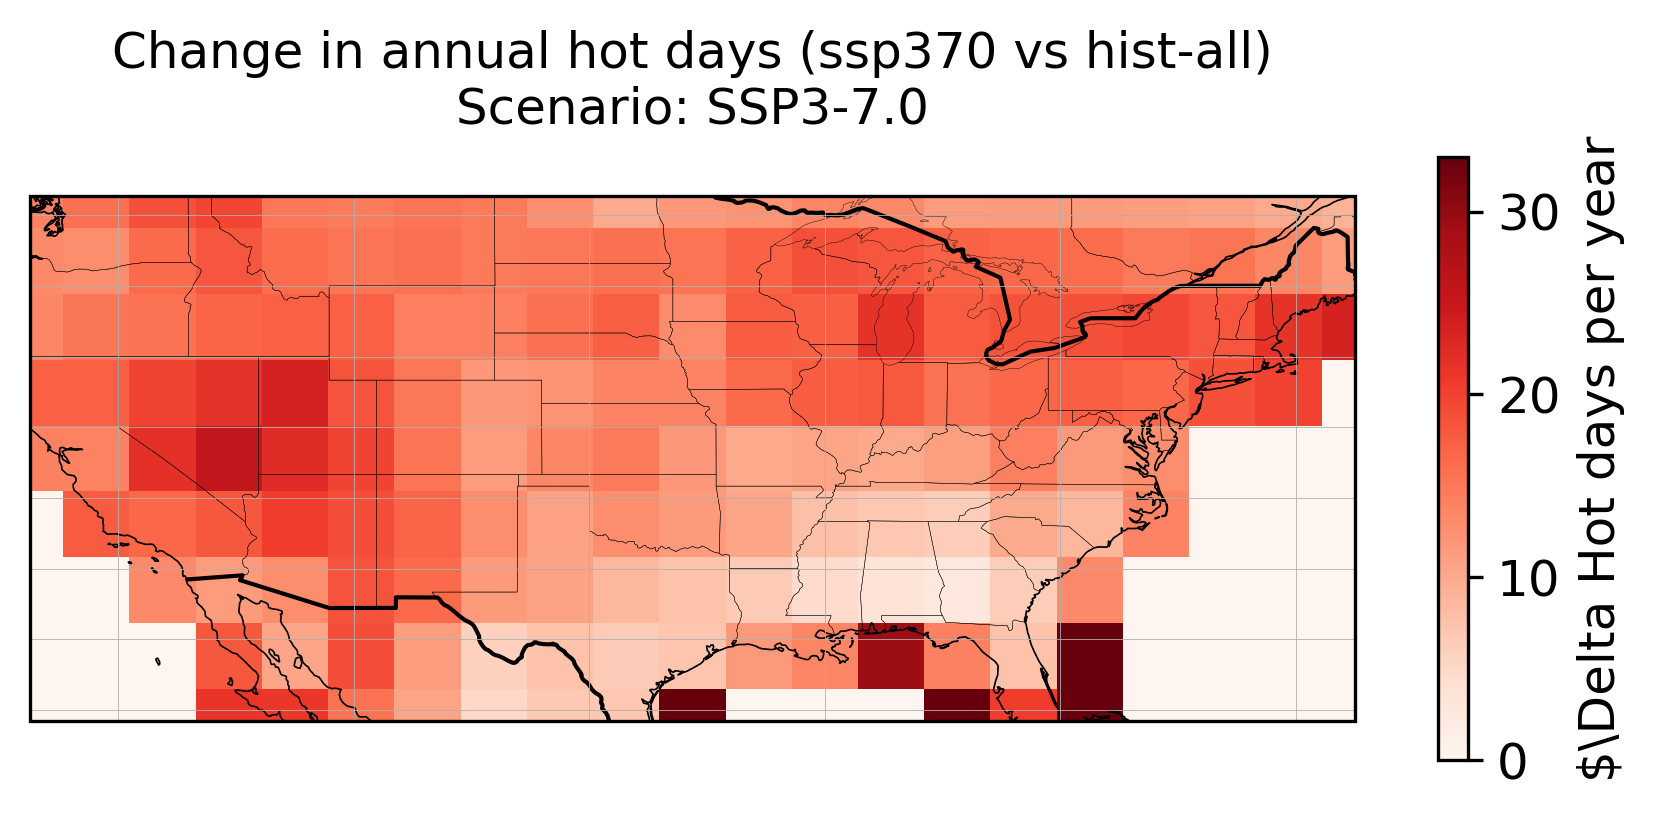

In [68]:

TITLE_FONTSIZE = 12
CBAR_LABELSIZE = 12
CBAR_TICKSIZE = 12
AX_TICKSIZE = 12

LON, LAT = np.meshgrid(lons_conus, lats_conus)

# 30-yr mean hot days per year, hist-all and SSP3-7.0 (per grid cell)
hist_mean = np.mean(hdays_hist_grid["all"], axis=0)        # (lat, lon)
fut_mean  = np.mean(hdays_future_grid["ssp370"], axis=0)   # (lat, lon)

diff_days = fut_mean - hist_mean

data = diff_days#.filled(np.nan)
vmin = np.nanpercentile(data, 2)
vmax = np.nanpercentile(data, 98)

fig, ax = plt.subplots(
    figsize=fig_size,
    dpi=300,
    tight_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

mesh = ax.pcolormesh(
    LON,
    LAT,
    diff_days,
    transform=ccrs.PlateCarree(),
    cmap=mpl.colormaps["Reds"],
    shading="nearest",
    vmin=vmin,
            vmax=vmax,
)

ax.coastlines(linewidth=0.4)
ax.add_feature(cfeature.STATES, linewidth=0.1)
ax.add_feature(cfeature.BORDERS, linewidth=1.0)
ax.set_extent(
    [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
    crs=ccrs.PlateCarree(),
)
ax.gridlines(draw_labels=False, linewidth=0.2)
ax.tick_params(labelsize=AX_TICKSIZE)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    shrink=0.5,
    #fraction=0.045,
    #pad=0.02,
)
cbar.ax.set_ylabel(r"$\Delta Hot days per year", fontsize=CBAR_LABELSIZE)
cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

ax.set_title(
    "Change in annual hot days (ssp370 vs hist-all)\nScenario: SSP3-7.0\n",
    fontsize=TITLE_FONTSIZE,
    pad=4,
)

fig.savefig(os.path.join(out_path, "hot_days_diff_ssp370_vs_hist.png"), bbox_inches="tight")
#plt.close(fig)

In [47]:
ls /global/u2/b/bharat/repos/hwconus/plots

cold_days_py.png                      slope_cold_all.png
diff_cold_days_all-nat.png            slope_cold_ghg.png
diff_cold_days_ghg-nat.png            slope_cold_nat.png
diff_cold_days_nat-nat.png            slope_heat_all.png
diff_cold_waves_all-nat.png           slope_heat_ghg.png
diff_cold_waves_ghg-nat.png           slope_heat_nat.png
diff_cold_waves_nat-nat.png           th_cold_all.png
diff_heat_days_all-nat.png            th_cold_ghg.png
diff_heat_days_ghg-nat.png            th_cold_nat.png
diff_heat_days_nat-nat.png            th_diff_cold_all-nat.png
diff_heat_waves_all-nat.png           th_diff_cold_ghg-nat.png
diff_heat_waves_ghg-nat.png           th_diff_cold_nat-nat.png
diff_heat_waves_nat-nat.png           th_diff_heat_all-nat.png
heat_waves_future_ssp370_vs_hist.png  th_diff_heat_ghg-nat.png
heat_waves_py.png                     th_diff_heat_nat-nat.png
hot_days_diff_ssp370_vs_hist.png      th_heat_all.png
hot_days_future_ssp370_vs_hist.png    th_heat_ghg.png
hot_days_p